# ERA5 vs the ARM observations at Utqiaġvik

Recreates the season phase-hour stack for the single ERA5 grid cell holding the
DOE ARM facility, then collapses it to the two categories Genie's observational
figure uses — **liquid containing** (red) and **ice only** (blue) — so the two
can be read side by side.

## What is and is not comparable

**The coloured hours are.** Both figures count hours per season in which a
liquid-containing or ice-only cloud was overhead at Utqiaġvik.

**Her precipitating categories are not separated here.** Genie splits
precipitating cases into lighter shades. This analysis applies no precipitation
filter, so:

| ERA5 category | corresponds to, in her figure |
|---|---|
| liquid containing | red **+** pink (`with liquid` + `with liquid (precip)`) |
| ice only | blue **+** light blue (`ice only` + `ice only (precip)`) |

**Bar heights are not.** Her bars run to the full season because she stacks
clear sky and a hatched *missing / no data* category on top. These bars stop at
the overcast total. Pass `include_clear=True` to add a grey remainder and match
her layout — the annotation still reports the overcast hours either way.

**ERA5 has no missing data.** A season short of hours is scaled up to the
nominal window rather than shown as a gap, so there is no counterpart to her
hatched bars. `--min-season-coverage` guards against that scaling being applied
to a badly incomplete season.

**Sampling differs.** ERA5 is a 0.25° grid-box average sampled hourly; the ARM
instruments see a point, far faster. Occupancy fractions compare; event
durations do not.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures/genie_comparison")

## Load the data

Set the season window and years to match the observational record you are
comparing against. Genie's figure runs 2015–2025.

In [2]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years, matching Genie's span
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.90,            # IWP/CWP at or above this = ice only

    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.95,          # overcast only
    lsm_tol=0.01,
    storage="local",
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    201

## 1. Three categories — liquid only, mixed phase, ice only

The figure from the per-class notebook, for the ARM cell alone. One grid cell,
so no averaging over cells is involved.

  -> figures/genie_comparison/barrow_season_phase_stack_site_mean2014-2024.png


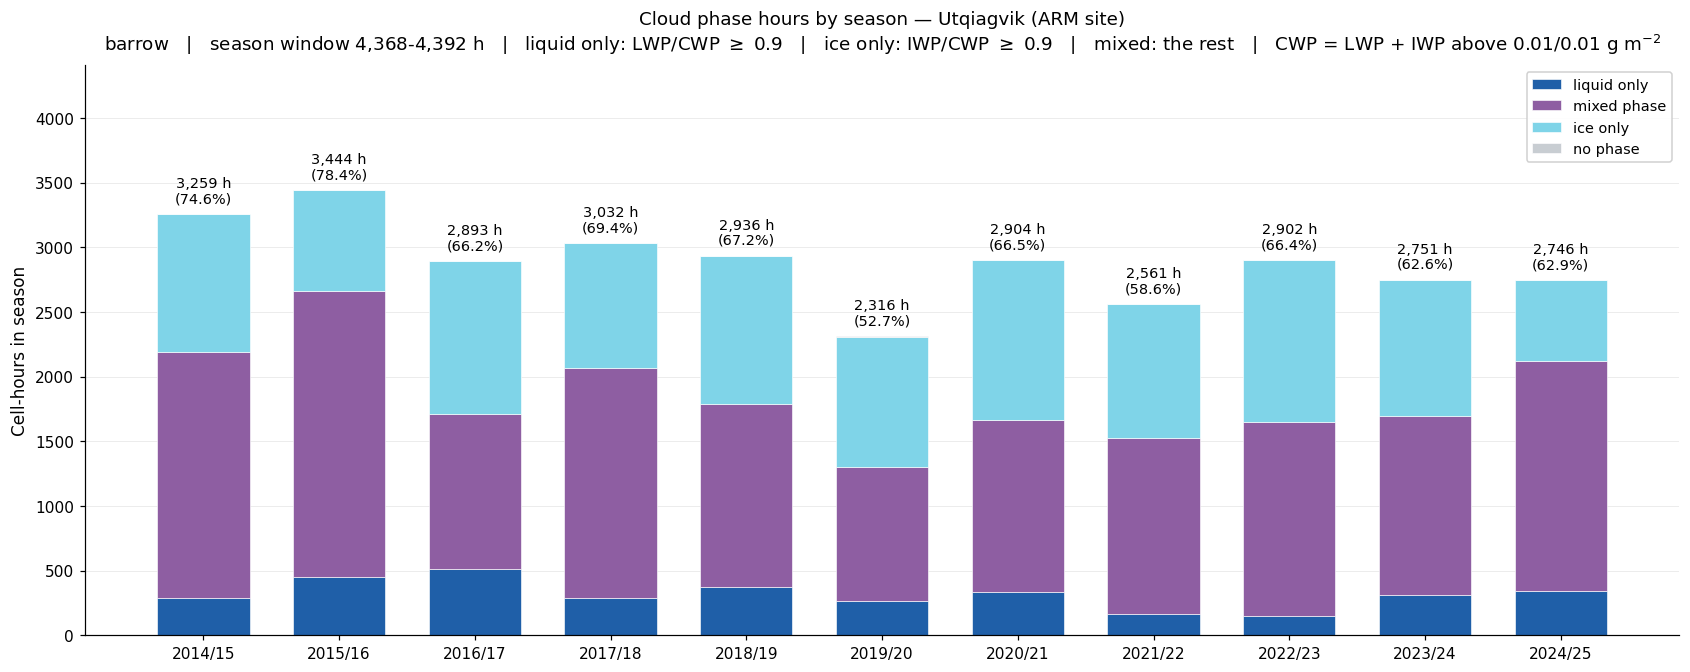

In [3]:
lwph.fig_season_phase_stack_site(A, out_dir=SAVE_DIR);

## 2. Two categories — liquid containing vs ice only

Liquid only and mixed phase are merged into **liquid containing**: both are
scenes an instrument would report as having liquid somewhere in the column. The
small *no phase* residual is folded into ice-only rather than dropped, so the
two still sum to the overcast total — it is overcast time carrying no cloud
water above the minimum paths, which nothing would call liquid.

Colours match Genie's figure exactly.

  -> figures/genie_comparison/barrow_season_phase_binary_site_mean2014-2024.png


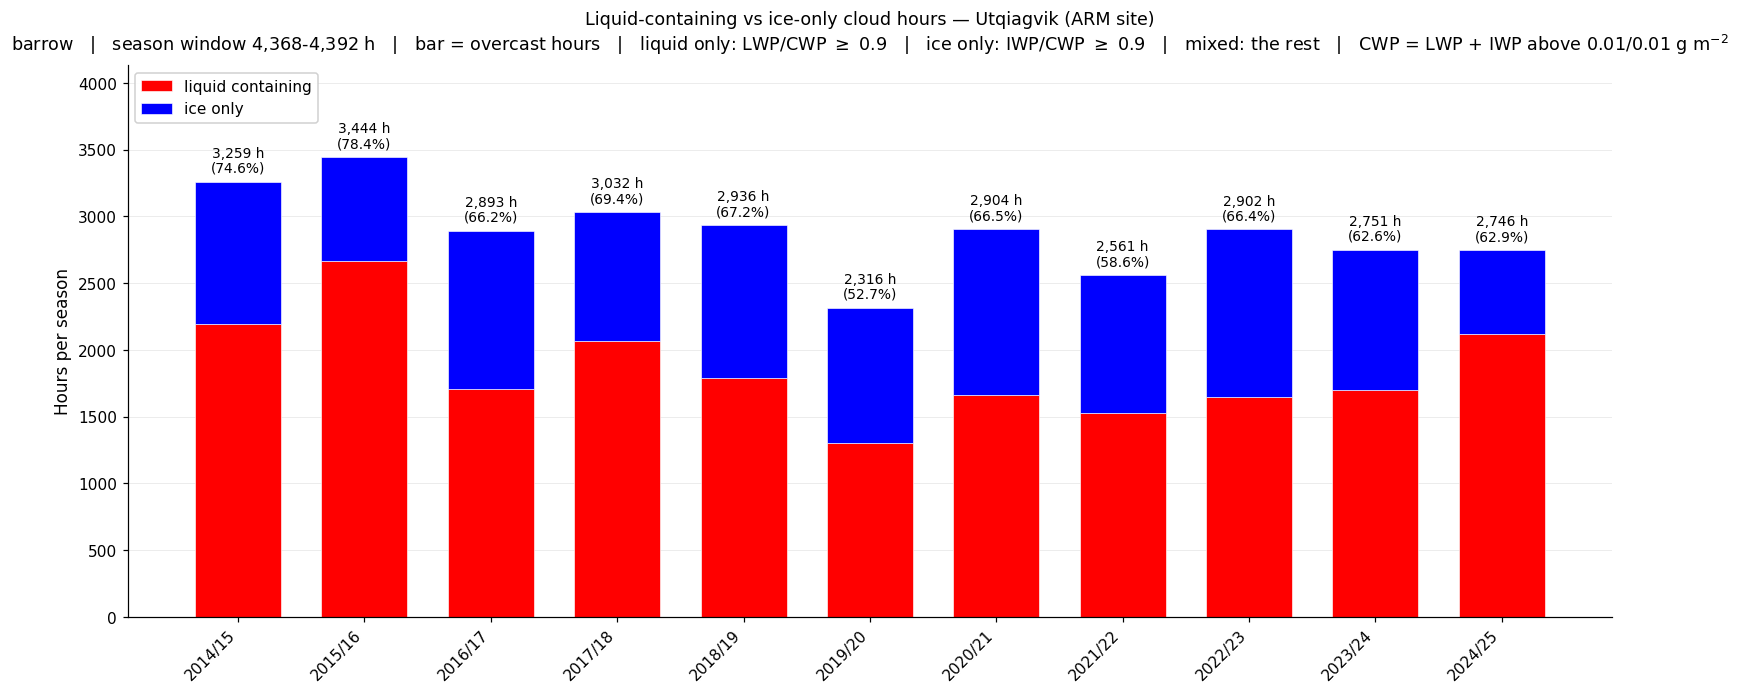

In [4]:
lwph.fig_season_phase_binary(A, out_dir=SAVE_DIR);

### The same, with clear sky stacked on top

Matches her layout, where each bar spans the whole season. The annotation still
gives the overcast hours, not the bar height.

  -> figures/genie_comparison/barrow_season_phase_binary_site_mean2014-2024.png


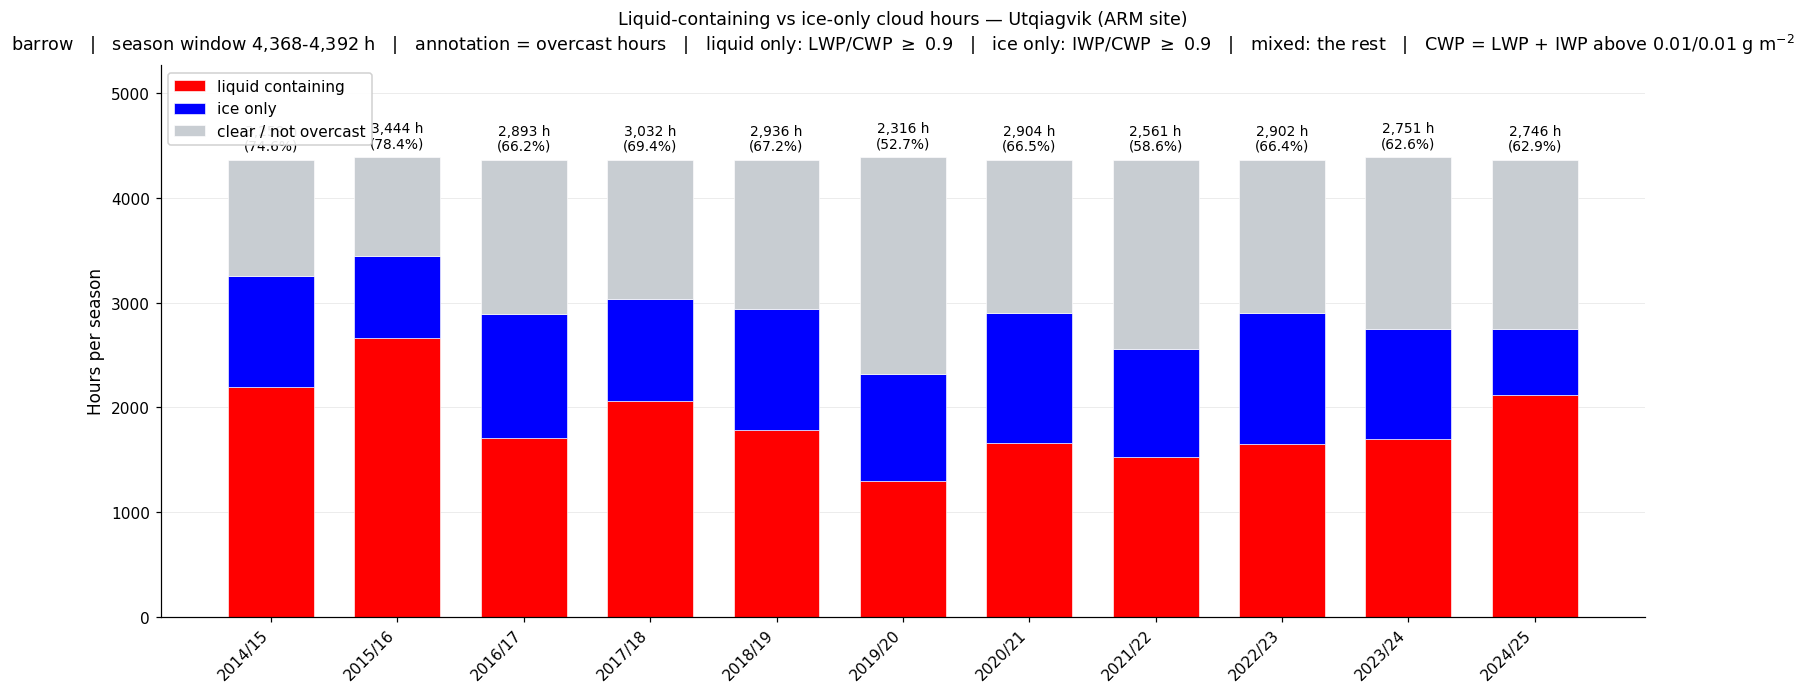

In [5]:
lwph.fig_season_phase_binary(A, include_clear=True, out_dir=SAVE_DIR);

## 3. The numbers, against hers

Her figure's legend gives the record means. The comparison to make is ERA5's
liquid-containing against her red **+** pink, and ERA5's ice-only against her
blue **+** light blue.

In [6]:
import numpy as np

labels, liquid, ice, clear, season_h = lwph.season_phase_binary(A)
code_i, series_label = lwph.resolve_series_code(A.col, "arm_site")
liq, ic = liquid[:, code_i], ice[:, code_i]

# season_h is per season now: a common-year Oct-Mar window is 182 days,
# a leap-year one 183, so there is no single window length to print.
print(f"{series_label} | season window {lwph.window_label(season_h)}\n")
print(f"  {'season':<10}{'liquid-cont':>13}{'ice only':>11}{'cloudy':>10}"
      f"{'% season':>10}{'liq share':>11}")
for i, lab in enumerate(labels):
    tot = liq[i] + ic[i]
    print(f"  {lab:<10}{liq[i]:>13,.0f}{ic[i]:>11,.0f}{tot:>10,.0f}"
          f"{100 * tot / season_h[i]:>9.1f}%{100 * liq[i] / tot:>10.1f}%")

print(f"\n  ERA5 mean        liquid-containing {liq.mean():>7,.0f} h"
      f"   ice-only {ic.mean():>7,.0f} h"
      f"   liquid share {100 * liq.mean() / (liq.mean() + ic.mean()):.1f}%")

# Genie's own numbers, straight from the file -- no longer the legend means
# typed in by hand, since the file now holds every season exactly.
o_l_np, o_i_np = lwph.obs_binary(obs_tbl := lwph.load_observations(),
                                 exclude_precip=True)
o_l_all, o_i_all = lwph.obs_binary(obs_tbl, exclude_precip=False)
print(f"  ARM  no precip   liquid-containing {o_l_np.mean():>7,.0f} h"
      f"   ice-only {o_i_np.mean():>7,.0f} h"
      f"   liquid share {100 * o_l_np.mean() / (o_l_np.mean() + o_i_np.mean()):.1f}%")
print(f"  ARM  all sky     liquid-containing {o_l_all.mean():>7,.0f} h"
      f"   ice-only {o_i_all.mean():>7,.0f} h"
      f"   liquid share {100 * o_l_all.mean() / (o_l_all.mean() + o_i_all.mean()):.1f}%")
print(f"  ERA5 - ARM (all sky) {liq.mean() - o_l_all.mean():>+17,.0f} h"
      f"{ic.mean() - o_i_all.mean():>+19,.0f} h")


Utqiagvik (ARM site) | season window 4,368-4,392 h

  season      liquid-cont   ice only    cloudy  % season  liq share
  2014/15           2,191      1,068     3,259     74.6%      67.2%
  2015/16           2,663        781     3,444     78.4%      77.3%
  2016/17           1,708      1,185     2,893     66.2%      59.0%
  2017/18           2,063        969     3,032     69.4%      68.0%
  2018/19           1,787      1,149     2,936     67.2%      60.9%
  2019/20           1,299      1,017     2,316     52.7%      56.1%
  2020/21           1,664      1,240     2,904     66.5%      57.3%
  2021/22           1,523      1,038     2,561     58.6%      59.5%
  2022/23           1,648      1,254     2,902     66.4%      56.8%
  2023/24           1,696      1,055     2,751     62.6%      61.7%
  2024/25           2,121        625     2,746     62.9%      77.2%

  ERA5 mean        liquid-containing   1,851 h   ice-only   1,035 h   liquid share 64.1%
  ARM  no precip   liquid-containing   1,6

## 4. The precipitation filter

### Use `tp`, and no download is needed

The published convention for "ERA5 says it is precipitating" is **0.1 mm hr⁻¹**
([Zhang et al. 2024, *J. Climate*](https://journals.ametsoc.org/view/journals/clim/37/5/JCLI-D-23-0302.1.xml)),
chosen to match a rain gauge's minimum measurable amount. That threshold is
defined on a **rate**, and ERA5 carries the rate directly as `tp` — total
precipitation, accumulated over the hour ending at the validity time, in metres
of water equivalent. So `mm hr⁻¹ = tp × 1000`.

**It is already in the archive.** Checked: present in all 654 single-level
files, finite everywhere, covering every season 2014/15–2025/26 at 93–100% of
the Oct–Mar window. It is also already in all three downloader variable sets
(`core`, `recommended`, `extended`), so future downloads keep it. Nothing to
download and nothing to add.

### Why not the column water paths

`tcrw + tcsw` is a suspended **mass path**, not a rate, so using it means
inferring a rate from a burden — which needs a fall speed and a layer depth
neither of which ERA5 gives you. I calibrated that route against `tp` in your
own data and it tops out around 94% agreement:

| | value |
|---|---|
| median rain+snow path where `tp` = 0.08–0.12 mm hr⁻¹ | 48.8 g m⁻² |
| physical `W = R·H/v`, H = 1 km, rain (v = 4 m/s) | 6.9 g m⁻² |
| same, snow (v = 1 m/s) | 27.8 g m⁻² |
| 5th–95th percentile of the path at `tp` ≥ 0.1 mm hr⁻¹ | **21–599 g m⁻²** |

That last row is the point: the burden corresponding to a given rate spans more
than an order of magnitude, so *no* mass-path cut reproduces the rate cut
cleanly. There is no reason to accept that error when the rate itself is on
disk. `precip_var="path"` remains available for comparison, but `"rate"` is now
the default.

### Why it matters for the observations

Genie separates precipitating cases into their own categories, so the filter is
what makes the two sides mean the same thing:

| ERA5 setting | compared against |
|---|---|
| `no_precip=False` | her red **+** pink, blue **+** light blue |
| `no_precip=True` | her red and blue **alone** |

`fig_era5_vs_obs` reads `A.args.no_precip` and picks the matching observation
columns automatically, so the pairing cannot drift out of sync with the run.

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    201

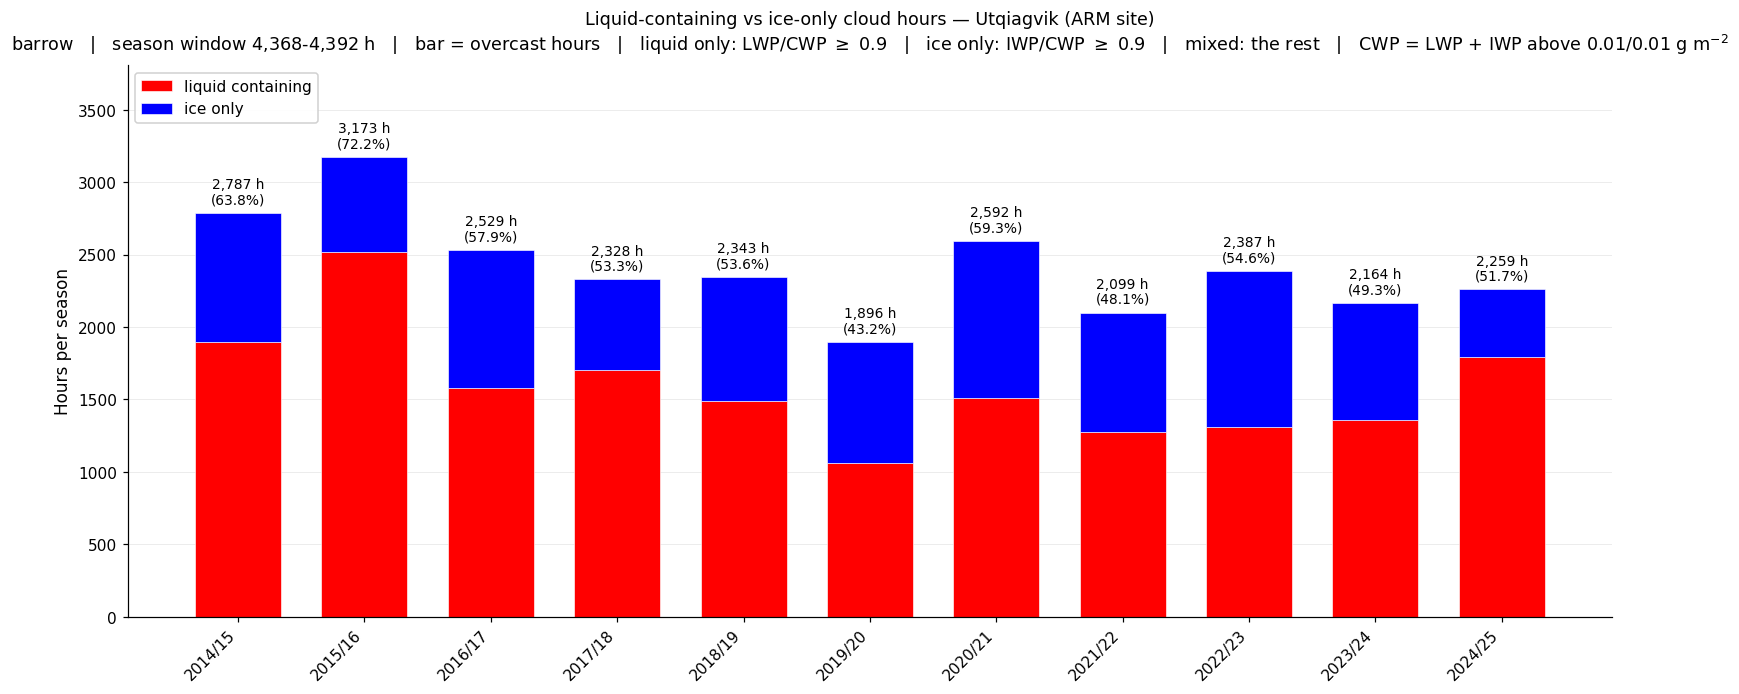

In [35]:
A_precip = lwph.prepare(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years, matching Genie's span
    season_start=(10, 1), season_end=(3, 31),
    phase_mode="fraction", liquid_fraction_min=0.90, ice_fraction_min=0.90,
    min_lwp=0.01, min_iwp=0.01, min_cloud_fraction=0.95, lsm_tol=0.01,
    storage="local",

    no_precip=True,             # <- the filter
    precip_var="rate",          # tp, the quantity the 0.1 mm/hr convention uses
    precip_rate_max=0.05,        # mm hr-1
)

removed = A_precip.col["precip_removed"]
before = A_precip.col["cloudy_before_precip"]
print(f"precip filter removed {100 * removed / before:.1f}% of cloudy cell-hours")
lwph.fig_season_phase_binary(A_precip, out_dir=SAVE_DIR);

## 5. ERA5 beside the observations, with residuals

### About the observation file

`genie_arm_seasonal_hours.txt` holds **Genie's exact numbers, ver2**. It is
generated by `build_genie_seasonal_hours.py` from her source files, kept
beside the code under `genie_obs_source/` — edit those and re-run, never the
table itself.

**The ver2 correction (2026-09-16).** Genie's first table (2026-09-01) had
left mixed-phase counts in the ice-only category. She re-supplied the two
non-precipitating categories as counts of 30 s samples
(`liquid_containing_clouds_yearly_totals_ver2.csv`,
`ice_only_clouds_yearly_totals_ver2.csv`; ÷120 for hours), in her words:
*"with liquid counts (including liquid and mixed phase clouds)"* and *"ice
counts (including only ice, no liquid or mixed phase)"*. The correction moves
about **215 h/season from ice-only to liquid-containing** — record means
with liquid 1474 → **1689 h**, ice only 1071 → **857 h**. Her published
legend predates the fix and no longer applies to those two categories.

**Genie's ver2 data are non-precipitating** (confirmed by Andrew,
2026-09-16). The numbers say the same thing: for every season, ver2
liquid + ice equals the original `With Liquid + Ice Only` to within 1 h
(asserted on build), so the correction moved hours between the two
non-precipitating rows and touched nothing else. The precipitating, clear-sky
and others rows are therefore carried over from the original table
unchanged, and the pairing rules below still hold: `no_precip=True` compares
against the ver2 columns alone, `no_precip=False` against ver2 + the original
precipitating categories. Note the precipitating categories were not
re-supplied — if her mixed-phase fix also touched them, that is not reflected
here.

**Missing data is unchanged.** The `missing` column is still derived, not
supplied — `season window − (the six categories)`, with a leap-aware window
(182 days, or 183 when the ending year is a leap year) — and because the
category total per season is unchanged by ver2, so is it. The same three
seasons are incomplete: **2016/17, 2019/20, 2020/21**. It averages 358
h/season against the 339 h her original legend stated, a 19 h gap that is
*not* explained; it only drives the incomplete-season flag, never a plotted
quantity.

**There is no digitisation uncertainty on the seasonal side.**
`OBS_SEASONAL_UNCERTAINTY_H` is 0, so the grey band draws nothing on these
figures even with `--show-digitization-uncert` set. Residuals here can be
read at face value. The **monthly** spreadsheet (section 7) is a separate
file and has **not** been re-supplied — if the mixed-phase misclassification
affected it too, section 7's ice-only and liquid-containing observations are
still the pre-fix values.

**Season labelling.** The original CSV's columns are headed `2014/15` …
`2024/25`; the ver2 files index seasons 0–10 in the same order. The table
uses the start year to match the ERA5 side, so `2014/15` is stored as 2014.
Eleven seasons.

### Two controls shared by sections 5, 6 and 7

**The threshold box.** Each figure now carries a corner box giving
`min cloud fraction` and the liquid-containing cut, so a saved PNG records the
run that made it. Note the direction of the second line: liquid-containing is
liquid-only **plus** mixed-phase, i.e. everything water-bearing that is *not*
ice-only, and ice-only is `IWP/CWP ≥ ice_fraction_min`. The boundary is
therefore

$$\frac{\mathrm{LWP}}{\mathrm{LWP}+\mathrm{IWP}} > 1 - \texttt{ice\_fraction\_min}$$

— **greater than** 10%, not less. `liquid_fraction_min` moves the
liquid-only/mixed boundary only, which this merge cannot see.

**`residual_mode`.** The lower panel takes `residual_mode="percent_diff"`
(the default, $100\,(\text{ERA5}-\text{obs})/\text{obs}$, normalised by the
**observed** value) or `residual_mode="hours"` (the raw difference). It is also
a CLI flag, `--residual-mode`, so `prepare()` can set it once for all three.
Where a band still applies — the monthly figure — it follows the units:
constant in hours, and per-bar in percent, since a fixed ±30 h is a larger
relative error on a small bar. The seasonal figures have no band any more.

observation seasons: 2014/15 .. 2024/25  (11 seasons)
  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024.png


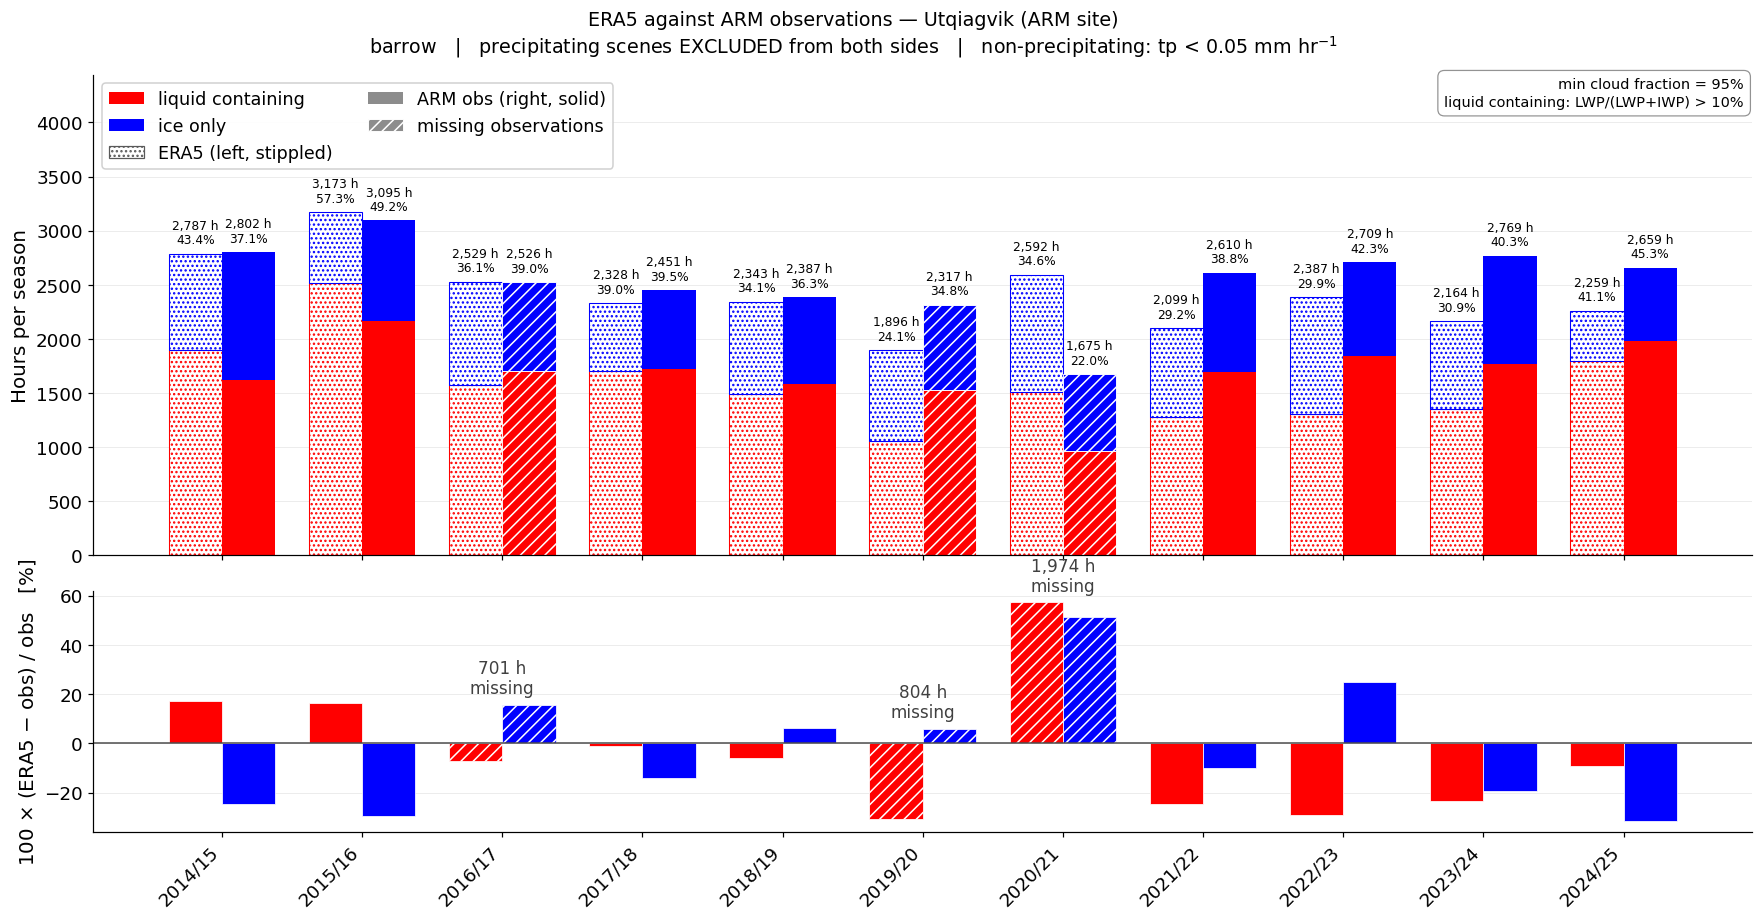

In [36]:
obs = lwph.load_observations()          # validates against the legend means
print(f"observation seasons: {obs['seasons'][0]}/{(obs['seasons'][0]+1)%100:02d}"
      f" .. {obs['seasons'][-1]}/{(obs['seasons'][-1]+1)%100:02d}"
      f"  ({len(obs['seasons'])} seasons)")

# Set USE_PRECIP_FILTER to choose which pairing to plot. The observation
# categories follow automatically.
USE_PRECIP_FILTER = True
A_cmp = A_precip if USE_PRECIP_FILTER else A

lwph.fig_era5_vs_obs(A_cmp, out_dir=SAVE_DIR);

In [37]:
# Same figure, upper panel only -- saved with a " - no-residual-panel" suffix.
# Not displayed here; plt.close() drops it before the cell finishes.
_fig = lwph.fig_era5_vs_obs(A_cmp, out_dir=SAVE_DIR, show_residual=False)
plt.close(_fig)

  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024 - no-residual-panel.png


### The slide build — frames 1 and 2 overlay exactly

For advancing through the comparison on slides: observations alone, then ERA5
appearing beside them. The two PNGs are written so that **nothing moves
between them** — same canvas, same axes, same observation bars, same legend and
threshold box — and the ERA5 bars appear in place.

Both use the **single-panel** layout, so the season labels sit directly under
the bars and there is no blank region where a residual panel would go. Frame 3,
the complete two-panel figure, is written as a separate image at its own size;
it is the backup slide and need not overlay the first two.

The two overlaying frames are saved with **one** bounding box: a per-frame
tight bbox would crop them differently and they would no longer line up.
`full_panel_frames=True` puts all three on the two-panel canvas instead, if the
residual panel is ever to be advanced to in the same slide position.

Files carry ` - build1-obs`, ` - build2-both`, ` - build3-full` suffixes.

The legend keeps its `ERA5` entry in frame 1 so the legend box does not change
size between frames.

  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024 - build1-obs.png
  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024 - build2-both.png
  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_mean2014-2024 - build3-full.png


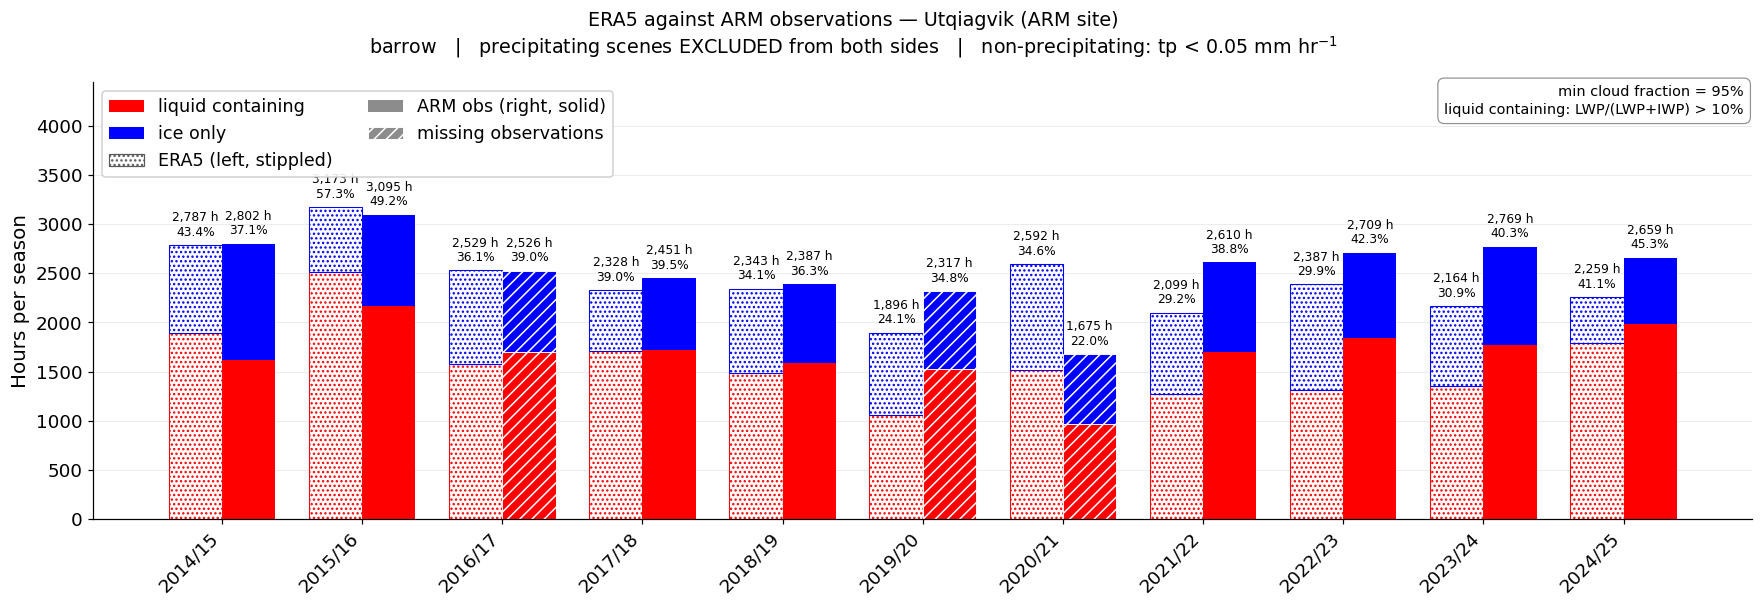

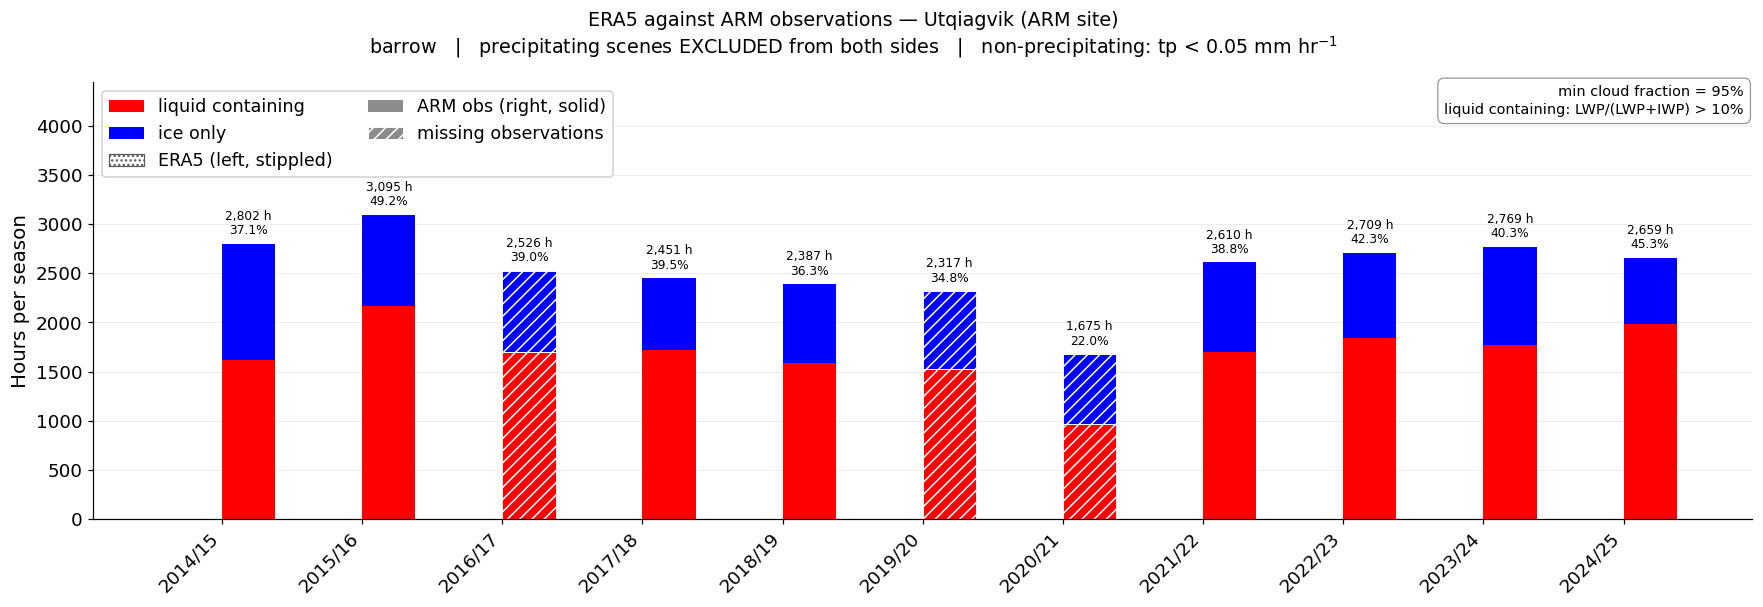

In [38]:
fig_obs, fig_both, fig_full = lwph.fig_era5_vs_obs_build(A_cmp, out_dir=SAVE_DIR)

# The full frame is already shown in the cell above; close it here so only the
# two new frames render inline.
plt.close(fig_full)

In [39]:
# Season-by-season residual table, same numbers as the lower panel above.
# Seasons with substantially incomplete observations are starred, shown in
# italics, and left out of the Average row. File name carries the two
# threshold settings so a saved table records the run that produced it.
lwph.table_era5_vs_obs_pct_diff(A_cmp, out_dir=SAVE_DIR, font_size=14);

  -> figures/genie_comparison/barrow_era5_vs_obs_noprecip_pct_diff_table_mcf0.95_ifm0.9.png


### Simplified comparison — ERA5 bars against one observed number

The same comparison stripped to its essentials: per season, two **solid**
bars side by side — ERA5's liquid-containing hours in red and its ice-only
hours in blue — and a single **dotted line** across the whole axes at the
observed mean of liquid-containing hours per season. No observation bars, no
residual panel. The line is a liquid-containing quantity and is read against
the red bars; the blue bars are there so the phase split stays visible.

**Where the line comes from.** `--obs-liquid-mean` / `obs_liquid_mean=` takes
either:

| setting | the line is |
|---|---|
| `"derived"` **(default)** | the mean over the **complete** seasons in `genie_arm_seasonal_hours.txt` (Genie's exact numbers from her CSV), computed by `obs_mean_liquid_hours` |
| a number | that many hours, used as given |

The derived value follows the run's precipitation filter, exactly as the
observation bars do in the figures above: with `no_precip=True` it is the
`with_liquid` column alone; without it, `with_liquid + liq_precip`.

**Incomplete seasons are excluded from the derived mean by default.** A
season counts as incomplete when its `missing` hours exceed 5% of the window
(`OBS_INCOMPLETE_FRAC`) — the same rule that stripes a bar in the figures
above and stars a row in the residual table. That drops **2016/17, 2019/20
and 2020/21** (700–1,970 h missing each), whose hours are lower bounds on what
the instruments would have seen. The effect is not small: with the ver2
file the no-precip mean is **1797 h over 8 complete seasons** against 1689 h
over all 11. `--obs-mean-include-incomplete` / `exclude_incomplete=False`
restores the all-season mean. The legend on the figure states the value, its
source, and how many seasons were excluded.

`show_ice=False` drops the blue bars. Files are saved under the
`era5_vs_obs_simple` stem; a custom value gets a ` - obs-mean-<value>h` suffix
so it never overwrites the derived figure.


  -> figures/genie_comparison/barrow_era5_vs_obs_simple_noprecip_mean2014-2024 - stacked.png


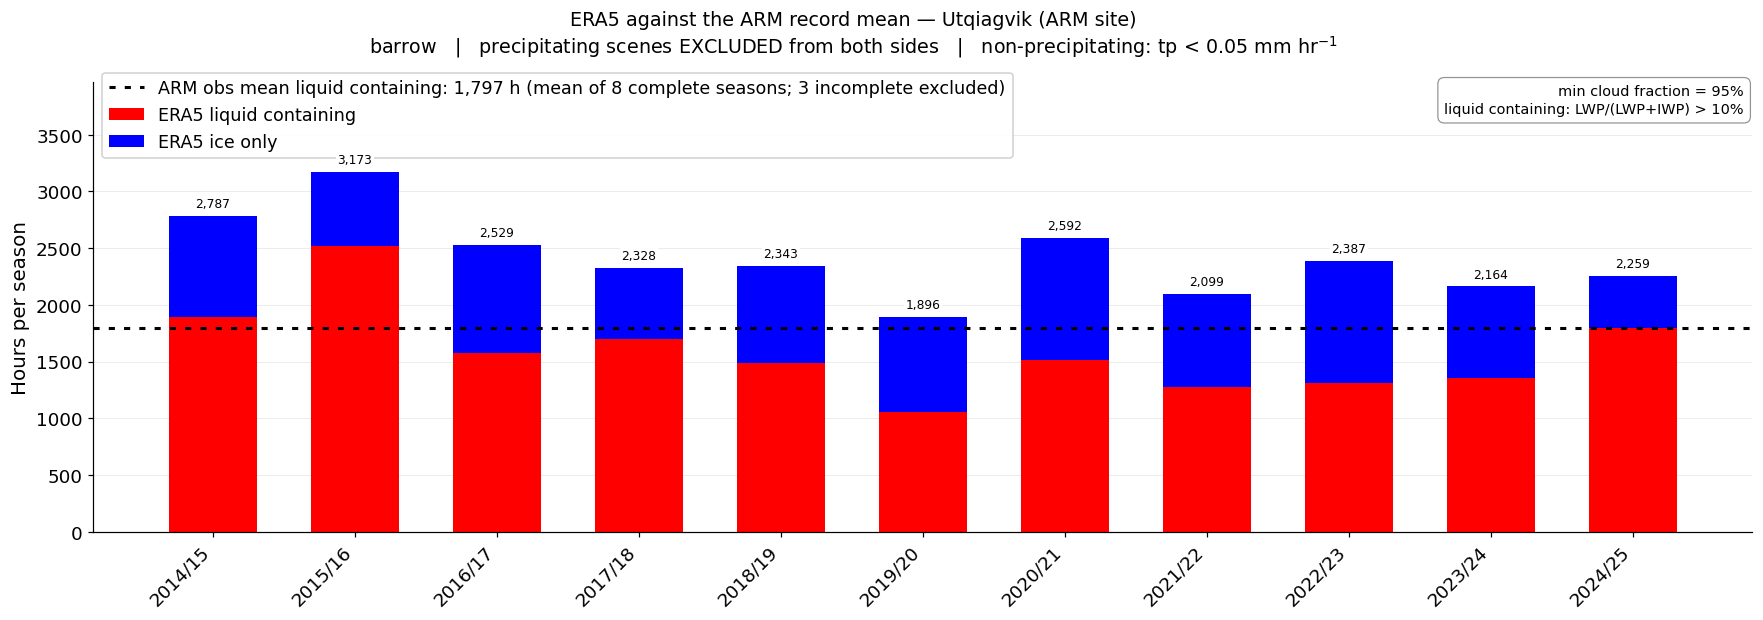

In [40]:
# Derived: the line is the record mean from the saved observation file,
# following A_cmp's precipitation filter. The legend states the value.
lwph.fig_era5_vs_obs_simple(A_cmp, out_dir=SAVE_DIR, bar_style='stacked');


  -> figures/genie_comparison/barrow_era5_vs_obs_simple_noprecip_mean2014-2024 - obs-mean-1500h.png
  derived mean, no precip:  1,797.5 h/season over  8 seasons  (excluding 2016/17, 2019/20, 2020/21)
  derived mean, no precip:  1,688.5 h/season over 11 seasons  (all seasons)
  derived mean, all sky  :  2,122.2 h/season over  8 seasons  (excluding 2016/17, 2019/20, 2020/21)
  derived mean, all sky  :  1,970.5 h/season over 11 seasons  (all seasons)


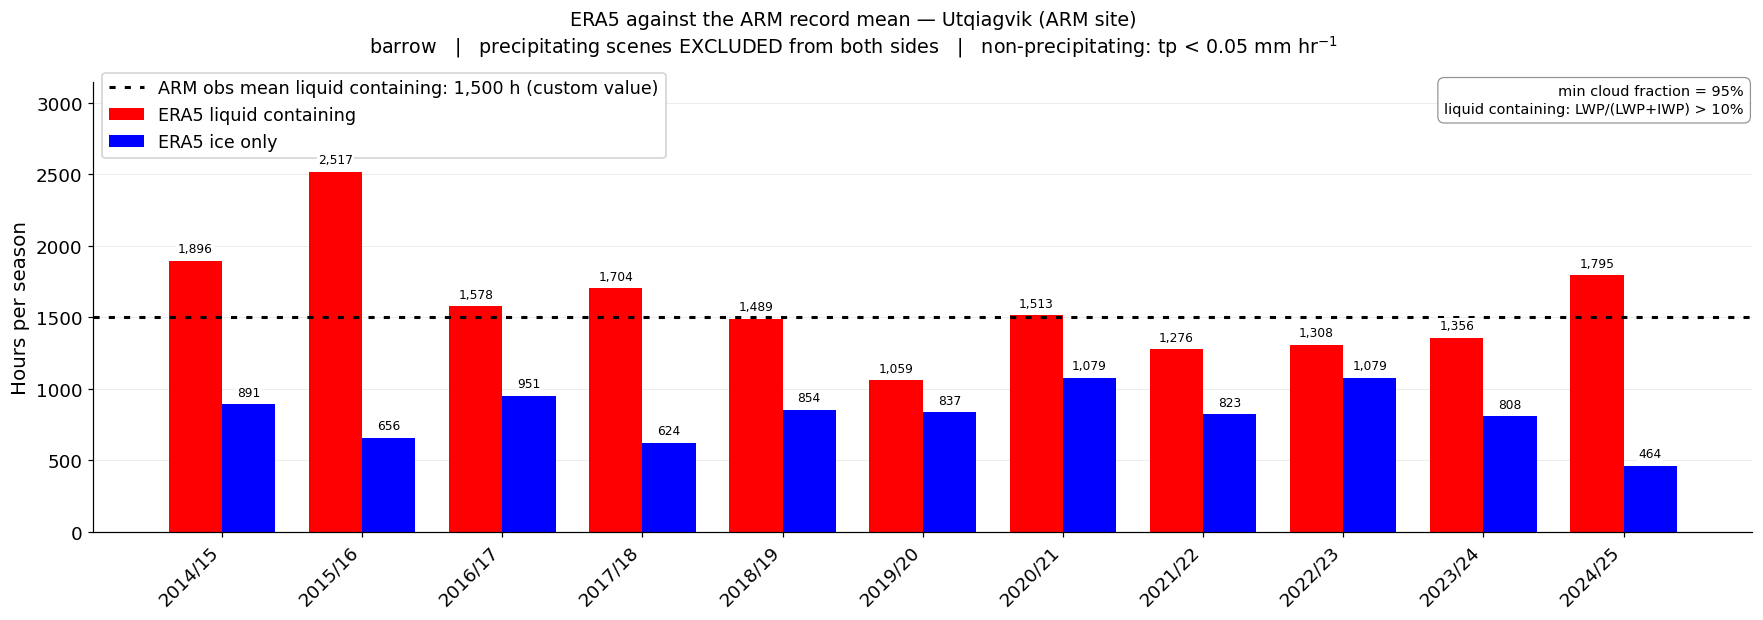

In [41]:
# Custom: the same figure with the line placed by hand. The value here is
# Genie's legend mean rounded, as a demonstration -- swap in whatever number
# the comparison needs. Saved under its own " - obs-mean-<value>h" suffix, so
# it does not overwrite the derived figure.
lwph.fig_era5_vs_obs_simple(A_cmp, obs_liquid_mean=1500, out_dir=SAVE_DIR);

# What the derived value is for each pairing, with and without the
# incomplete seasons, for reference.
for exclude_precip, tag in ((True, "no precip"), (False, "all sky")):
    for excl in (True, False):
        m, n, dropped = lwph.obs_mean_liquid_hours(
            obs, exclude_precip=exclude_precip, exclude_incomplete=excl)
        note = (f"excluding {', '.join(f'{y}/{(y+1)%100:02d}' for y in dropped)}"
                if dropped else "all seasons")
        print(f"  derived mean, {tag:<9}: {m:>8,.1f} h/season over {n:>2} "
              f"seasons  ({note})")


### Both pairings, side by side

Whether the filter helps is an empirical question, so run it both ways.

In [42]:
import numpy as np

for A_i, tag in ((A, "all-sky"), (A_precip, "precip filtered")):
    labels, liq, ice, _, sh = lwph.season_phase_binary(A_i)
    c, _ = lwph.resolve_series_code(A_i.col, "arm_site")
    o_l, o_i = lwph.obs_binary(obs, exclude_precip=A_i.args.no_precip)
    print(f"\n{tag}:")
    print(f"  ERA5  liquid-containing {liq[:, c].mean():>7,.0f} h"
          f"   ice-only {ice[:, c].mean():>7,.0f} h"
          f"   liquid share {100*liq[:, c].mean()/(liq[:, c].mean()+ice[:, c].mean()):.1f}%")
    print(f"  ARM   liquid-containing {o_l.mean():>7,.0f} h"
          f"   ice-only {o_i.mean():>7,.0f} h"
          f"   liquid share {100*o_l.mean()/(o_l.mean()+o_i.mean()):.1f}%")
    print(f"  diff  {liq[:, c].mean()-o_l.mean():>+22,.0f} h"
          f"{ice[:, c].mean()-o_i.mean():>+20,.0f} h")


all-sky:
  ERA5  liquid-containing   1,851 h   ice-only   1,035 h   liquid share 64.1%
  ARM   liquid-containing   1,971 h   ice-only   1,112 h   liquid share 63.9%
  diff                    -119 h                 -78 h

precip filtered:
  ERA5  liquid-containing   1,590 h   ice-only     824 h   liquid share 65.9%
  ARM   liquid-containing   1,689 h   ice-only     857 h   liquid share 66.3%
  diff                     -98 h                 -33 h


## 6. All sky — nothing filtered, obs precip shown separately

The companion to section 5. There, precipitating scenes are removed from ERA5
and the observations are compared on their non-precipitating categories alone.
Here **nothing is removed from either side**, and the observation bar breaks out
its precipitating categories as their own segments in Genie's shades, so the
part of the comparison the filter would have cut is visible rather than folded
in silently.

ERA5 has no counterpart to that split — the unfiltered run includes
precipitation but does not separate it — so its bar stays two segments. That
asymmetry is the point: it shows how much of the observed cloud time is
precipitating, which is exactly what section 5 removes.

Clear sky is not drawn, as asked. Bars are cloud hours only.

The observation stack is grouped **by phase** rather than in Genie's original
order, so the liquid block and the ice block are each contiguous and can be read
against the two-segment ERA5 bar beside them.

This needs the **unfiltered** `A`; passing `A_precip` raises rather than
silently comparing mismatched populations.

  -> figures/genie_comparison/barrow_era5_vs_obs_allsky_split_pct_mean2014-2024.png


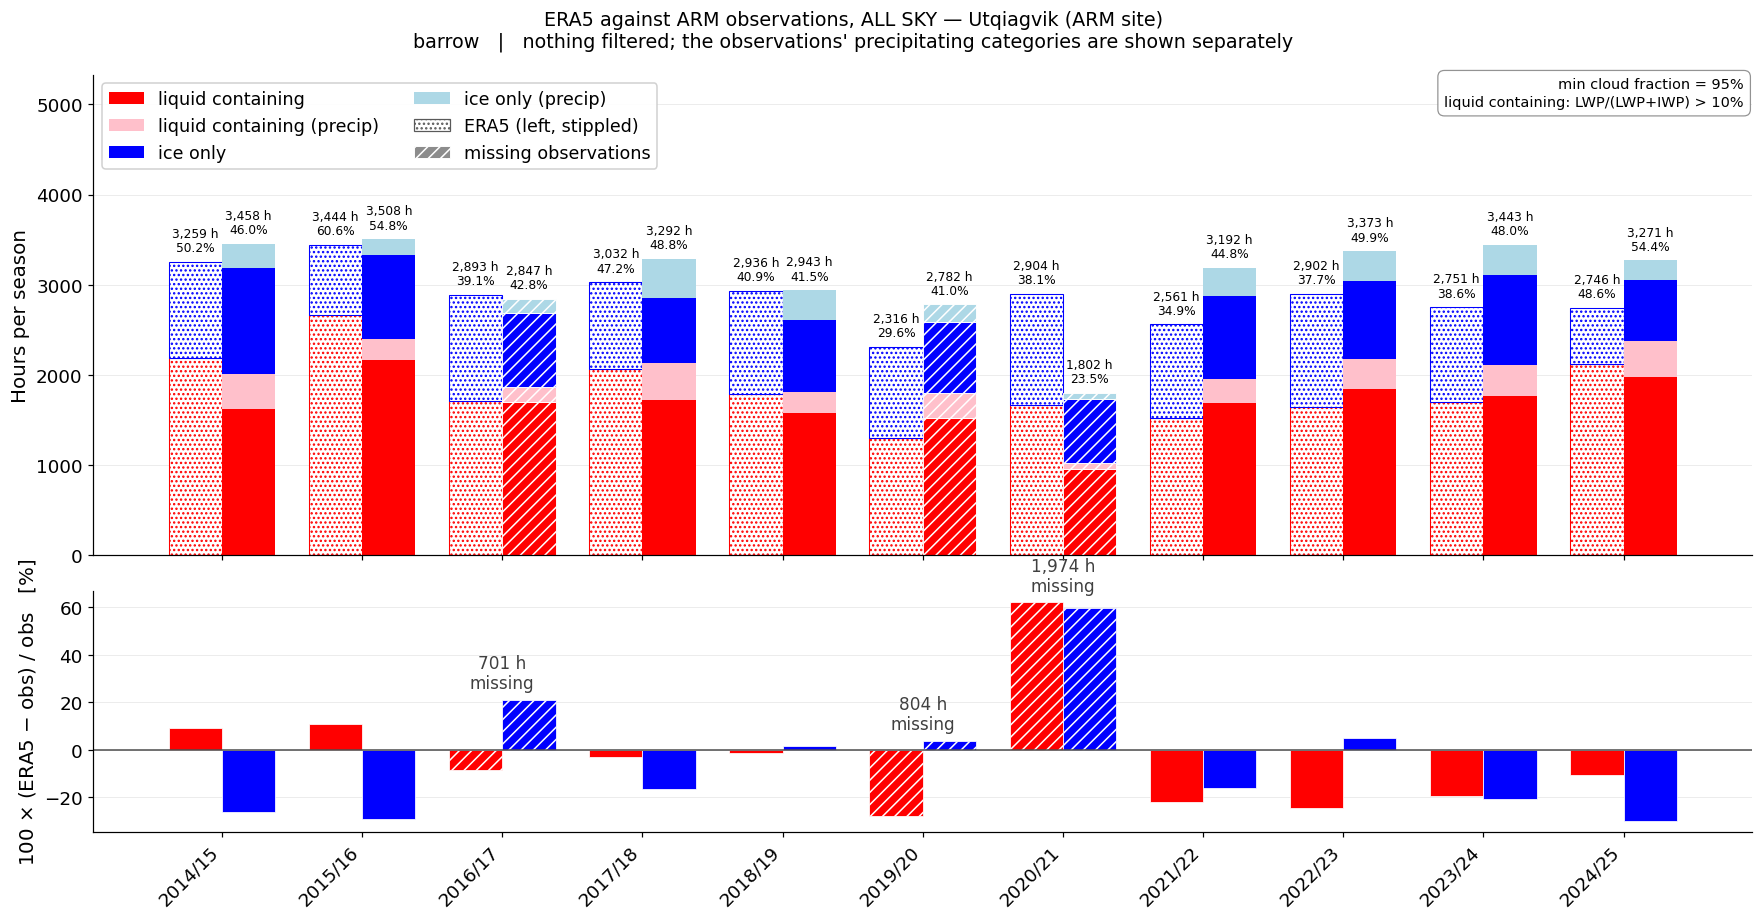

In [15]:
lwph.fig_era5_vs_obs_allsky(A, out_dir=SAVE_DIR);

In [16]:
# Same figure, upper panel only -- saved with a " - no-residual-panel" suffix.
# Not displayed here; plt.close() drops it before the cell finishes.
_fig = lwph.fig_era5_vs_obs_allsky(A, out_dir=SAVE_DIR, show_residual=False)
plt.close(_fig)

  -> figures/genie_comparison/barrow_era5_vs_obs_allsky_split_pct_mean2014-2024 - no-residual-panel.png


In [17]:
# Season-by-season residual table, same numbers as the lower panel above.
lwph.table_era5_vs_obs_allsky_pct_diff(A, out_dir=SAVE_DIR, font_size=14);

  -> figures/genie_comparison/barrow_era5_vs_obs_allsky_split_pct_diff_table_mcf0.95_ifm0.9.png


## 7. Monthly means — ERA5 against the observations

The season axis collapsed: for each calendar month, the mean over seasons of
that month's liquid-containing and ice-only hours, with the observations beside
it. Same layout as sections 5 and 6 — ERA5 stippled on the left, observations
solid on the right, residual underneath.

### The observation source

Two sources are available, chosen by `--monthly-obs-source` /
`obs_source=`:

| source | file | what it holds |
|---|---|---|
| `xlsx` **(default)** | `genie_arm_monthly_hours.xlsx`, tab `SUMMARY` | Genie's **exact** hours for every season × month, 2014/15–2024/25 |
| `digitized` | `genie_arm_monthly_hours.txt` | the six monthly **means** read off her figure by eye, before the spreadsheet arrived |

The spreadsheet is a copy of `SLCCounts_monthly.xlsx` as she supplied it, kept
beside the code so the notebook does not depend on a path in `~/Documents`.

**Months she highlighted yellow are missing data and are excluded from every
average.** The loader reads the cell fill directly rather than a transcribed
list, reproduces her own `AVERAGE` row to within 0.5 h (asserted on load), and
the figure cross-checks the yellow cells against `GENIE_EXCLUDED_MONTHS` on the
ERA5 side — a disagreement raises, because both sides must drop the same
months. The next cell shows the two agree exactly.

Because the spreadsheet holds every season, the observation bars now carry an
**across-season ±1 s.d. whisker** matching ERA5's, and the digitisation
uncertainty band is zero. The whisker on each side is interannual variability,
not uncertainty in the mean.

Both sources include precipitating cases, so an unfiltered ERA5 run is the
like-for-like comparison. The raw tabs of the spreadsheet
(`liquidCounts_precip_monthly`, `cloudCounts_precip_monthly`) do carry a
precipitation split by month — not yet wired in; see the note under the slide
build below.

In [18]:
import calendar

obs_x = lwph.load_monthly_observations(source="xlsx")        # the default
obs_d = lwph.load_monthly_observations(source="digitized")

print(f"xlsx: {obs_x['path']}   |   {len(obs_x['seasons'])} seasons x "
      f"{len(obs_x['months'])} months   |   uncertainty {obs_x['uncertainty_h']:g} h")
print(f"yellow cells  -> {obs_x['excluded_months']}")
print(f"ERA5 excludes -> {tuple(sorted(lwph.GENIE_EXCLUDED_MONTHS))}")
print("IDENTICAL\n" if set(obs_x["excluded_months"]) == set(lwph.GENIE_EXCLUDED_MONTHS)
      else "*** THE TWO LISTS DIFFER ***\n")

di = {m: i for i, m in enumerate(obs_d["months"])}
print(f"{'month':<6}{'n':>3}{'xlsx liq':>10}{'sd':>6}{'digit':>8}{'diff':>7}"
      f"{'xlsx ice':>11}{'sd':>6}{'digit':>8}{'diff':>7}")
for j, m in enumerate(obs_x["months"]):
    xl, xi = obs_x["with_liquid"][j], obs_x["ice_only"][j]
    dl, dii = obs_d["with_liquid"][di[m]], obs_d["ice_only"][di[m]]
    print(f"{calendar.month_abbr[m]:<6}{obs_x['n_per_month'][j]:>3}{xl:>10.1f}"
          f"{obs_x['sd_with_liquid'][j]:>6.0f}{dl:>8.0f}{xl-dl:>+7.1f}"
          f"{xi:>11.1f}{obs_x['sd_ice_only'][j]:>6.0f}{dii:>8.0f}{xi-dii:>+7.1f}")
print("\nThe digitised means were within 2.2 h of her exact numbers -- the "
      "+/-30 h read-off\nbudget was conservative by an order of magnitude.")

xlsx: genie_arm_monthly_hours.xlsx   |   11 seasons x 6 months   |   uncertainty 0 h
yellow cells  -> ((2020, 1), (2020, 10), (2020, 11), (2020, 12), (2021, 11), (2023, 2), (2023, 10))
ERA5 excludes -> ((2020, 1), (2020, 10), (2020, 11), (2020, 12), (2021, 11), (2023, 2), (2023, 10))
IDENTICAL

month   n  xlsx liq    sd   digit   diff   xlsx ice    sd   digit   diff
Oct     9     500.1    94     500   +0.1      157.3    51     158   -0.7
Nov     9     426.2    89     425   +1.2      187.8    59     190   -2.2
Dec    10     283.3   117     283   +0.3      248.7    70     250   -1.3
Jan    10     261.4    91     260   +1.4      248.4    44     249   -0.6
Feb    10     201.3    88     201   +0.3      245.3    84     246   -0.7
Mar    11     226.0    58     225   +1.0      309.1    74     310   -0.9

The digitised means were within 2.2 h of her exact numbers -- the +/-30 h read-off
budget was conservative by an order of magnitude.


  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024.png


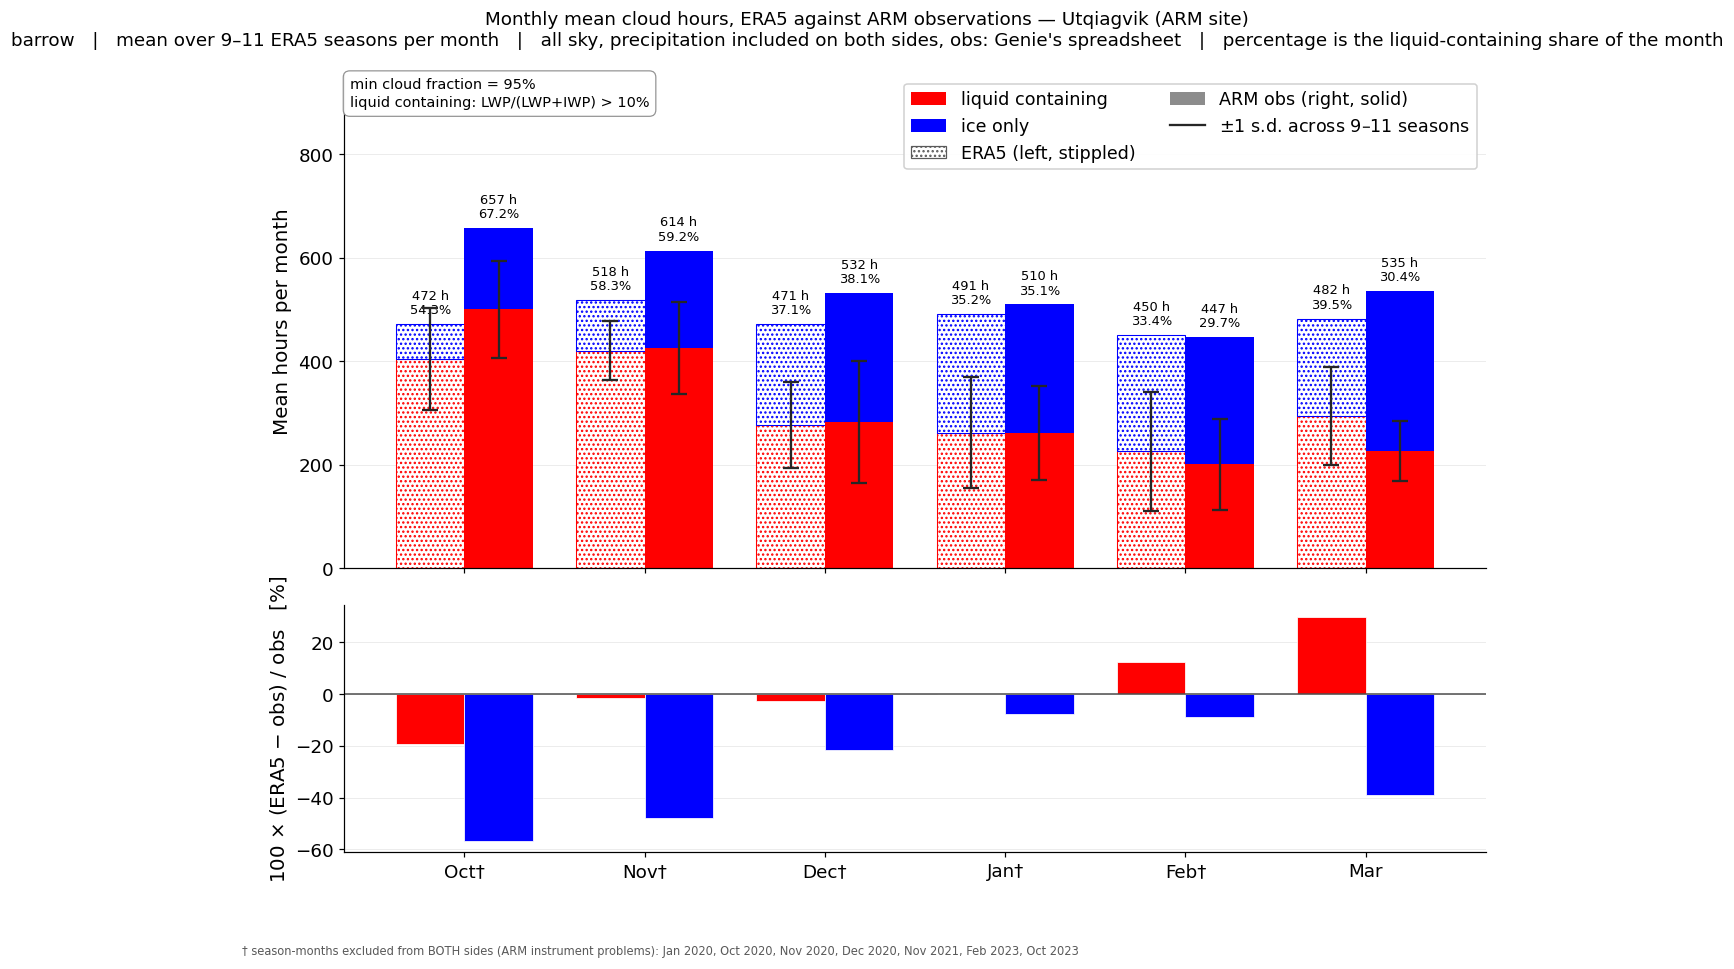

In [19]:
lwph.fig_monthly_era5_vs_obs(A, out_dir=SAVE_DIR);

In [20]:
# Same figure, upper panel only -- saved with a " - no-residual-panel" suffix.
# Not displayed here; plt.close() drops it before the cell finishes.
_fig = lwph.fig_monthly_era5_vs_obs(A, out_dir=SAVE_DIR, show_residual=False)
plt.close(_fig)

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024 - no-residual-panel.png


### The slide build — two variants, three frames each

The same construction as section 5, twice: once **all sky** and once with the
**precipitation filter** from section 5 (`A_precip`, `tp < 0.05 mm hr⁻¹`).
Within each variant, frames 1 and 2 share one bounding box and overlay exactly;
frame 3 is the complete two-panel figure at its own size.

**The filtered variant is not a like-for-like comparison, and the figure says
so.** The `SUMMARY` tab's two categories include precipitating cases — so the ERA5 bars exclude precipitation while the
observation bars still include it. The function refuses to draw this unless
`allow_precip_mismatch=True` is passed, and then states the mismatch on its own
title line. What the pair of variants *does* show cleanly is how much of ERA5's
own cloud time the filter removes, month by month; the residual against the
observations in the filtered variant should not be read as a model error.

Files: all-sky frames carry ` - build1-obs` … under the existing
`monthly_era5_vs_obs` stem (unchanged, so nothing that referenced it breaks);
filtered frames use `monthly_era5_vs_obs_noprecip`.

**This can now be fixed.** The spreadsheet's raw tabs carry a monthly
precipitation split (`liquidCounts_monthly` is the non-precipitating liquid
count; `liquidCounts_precip_monthly` the precipitating part; `SUMMARY`'s
`WITH LIQUID` is their sum). Reading those would give a like-for-like
observation side for the filtered variant and retire `allow_precip_mismatch`.
Not wired in yet — the ice-only non-precip counterpart needs confirming from
`cloudCounts_monthly` first.

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024 - build1-obs.png
  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024 - build2-both.png
  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_mean2014-2024 - build3-full.png


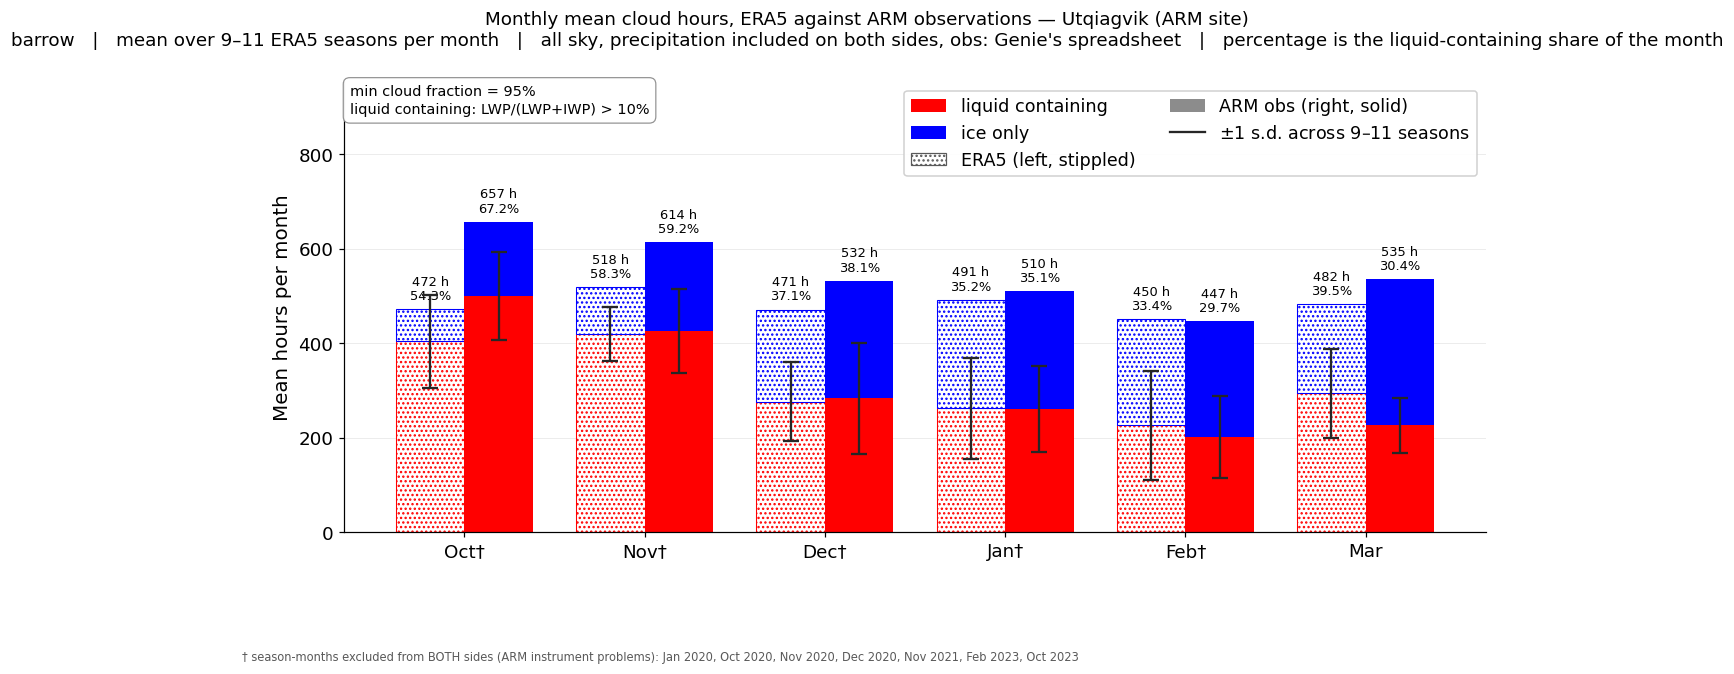

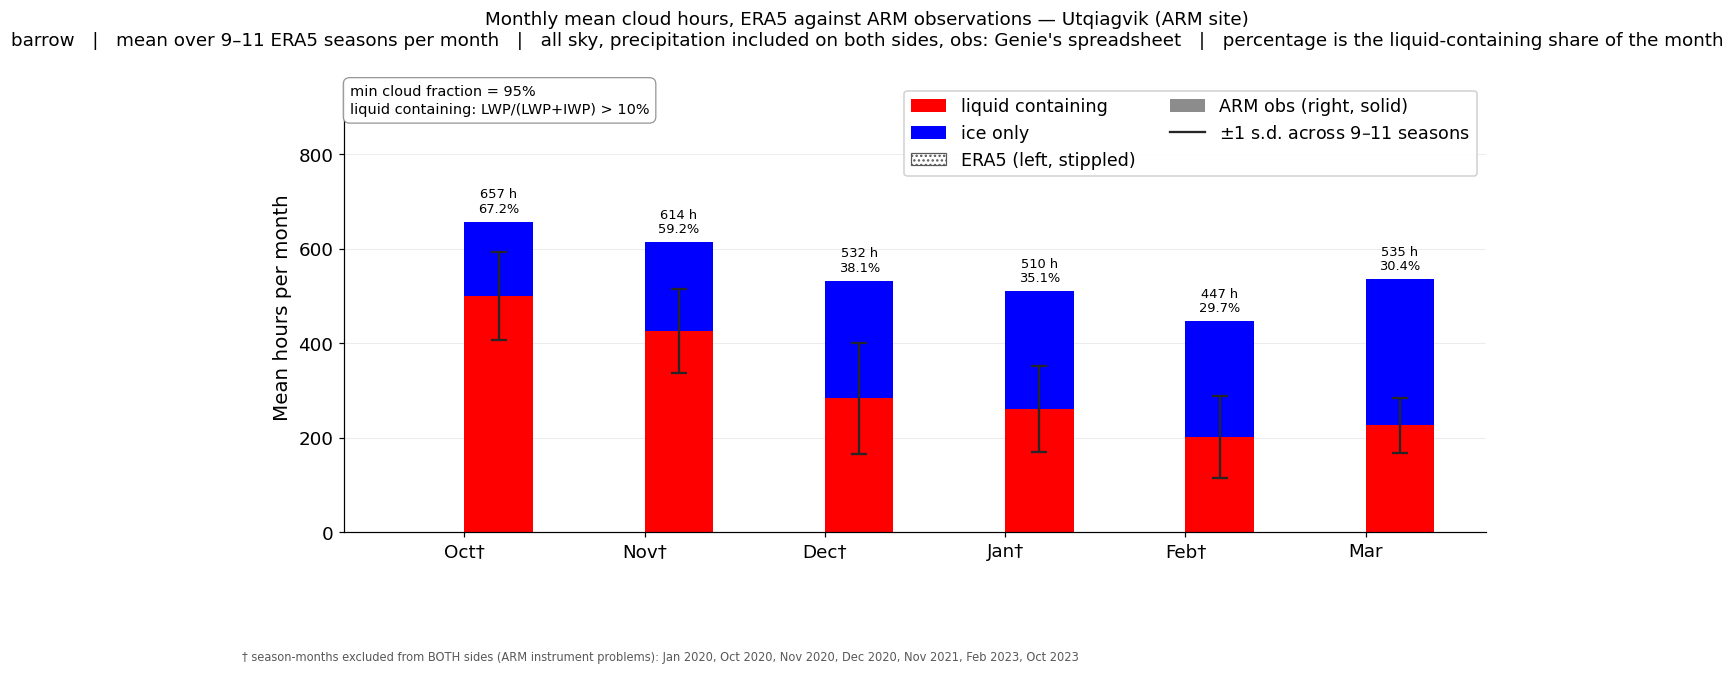

In [21]:
# All sky -- like-for-like with the observations.
m_obs, m_both, m_full = lwph.fig_monthly_era5_vs_obs_build(A, out_dir=SAVE_DIR)
plt.close(m_full)     # already shown above

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_noprecip_pct_mean2014-2024 - build1-obs.png
  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_noprecip_pct_mean2014-2024 - build2-both.png
  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_noprecip_pct_mean2014-2024 - build3-full.png


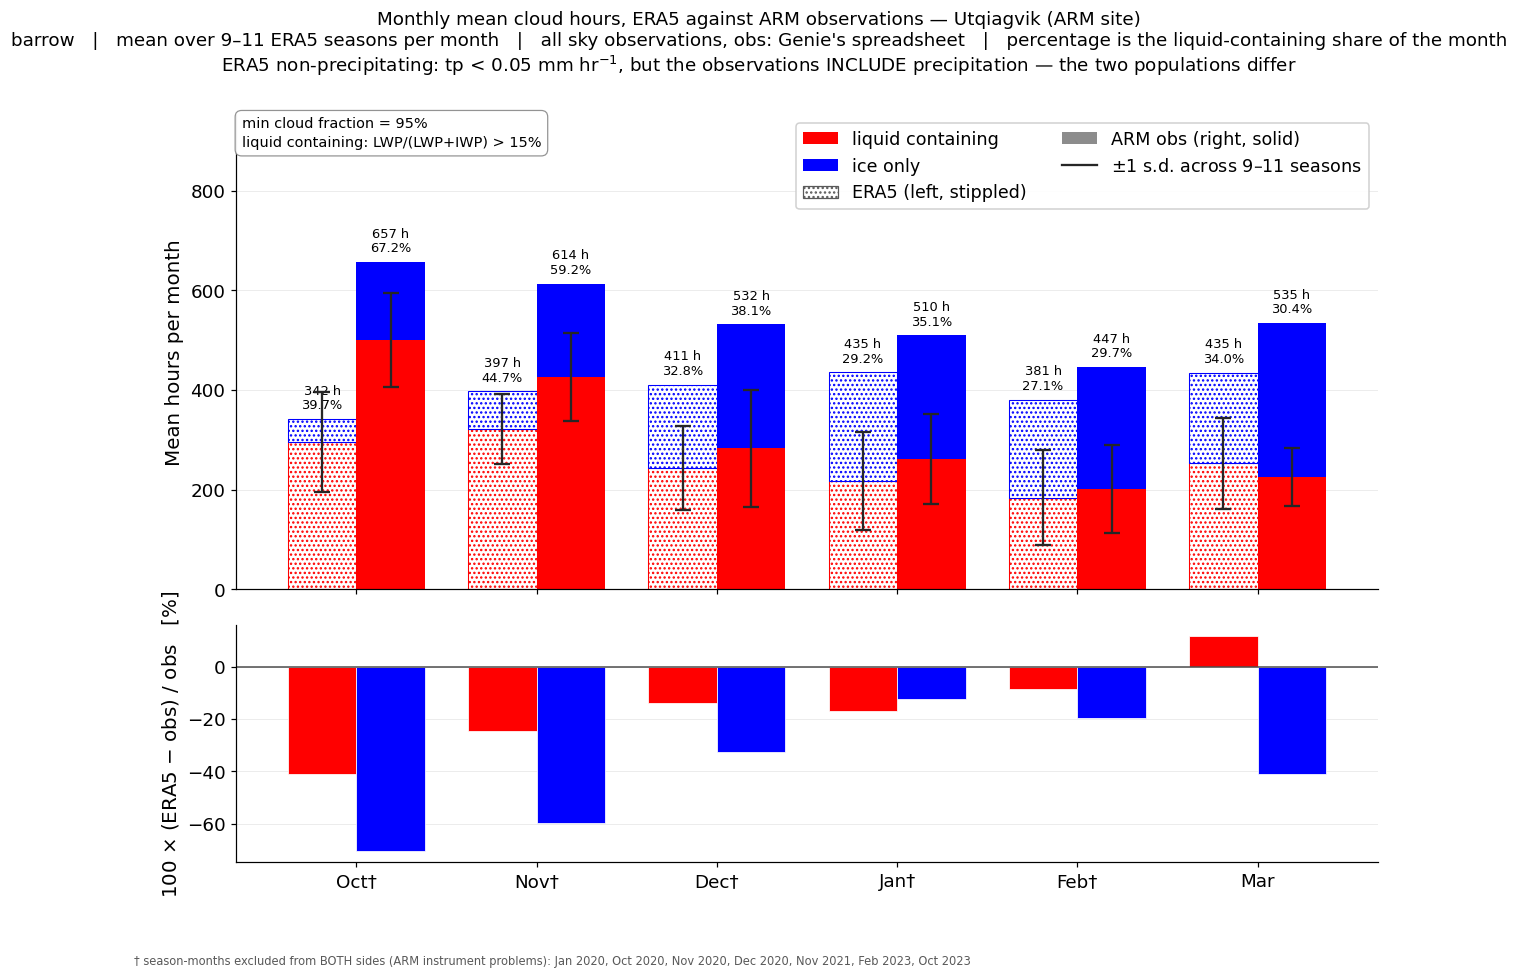

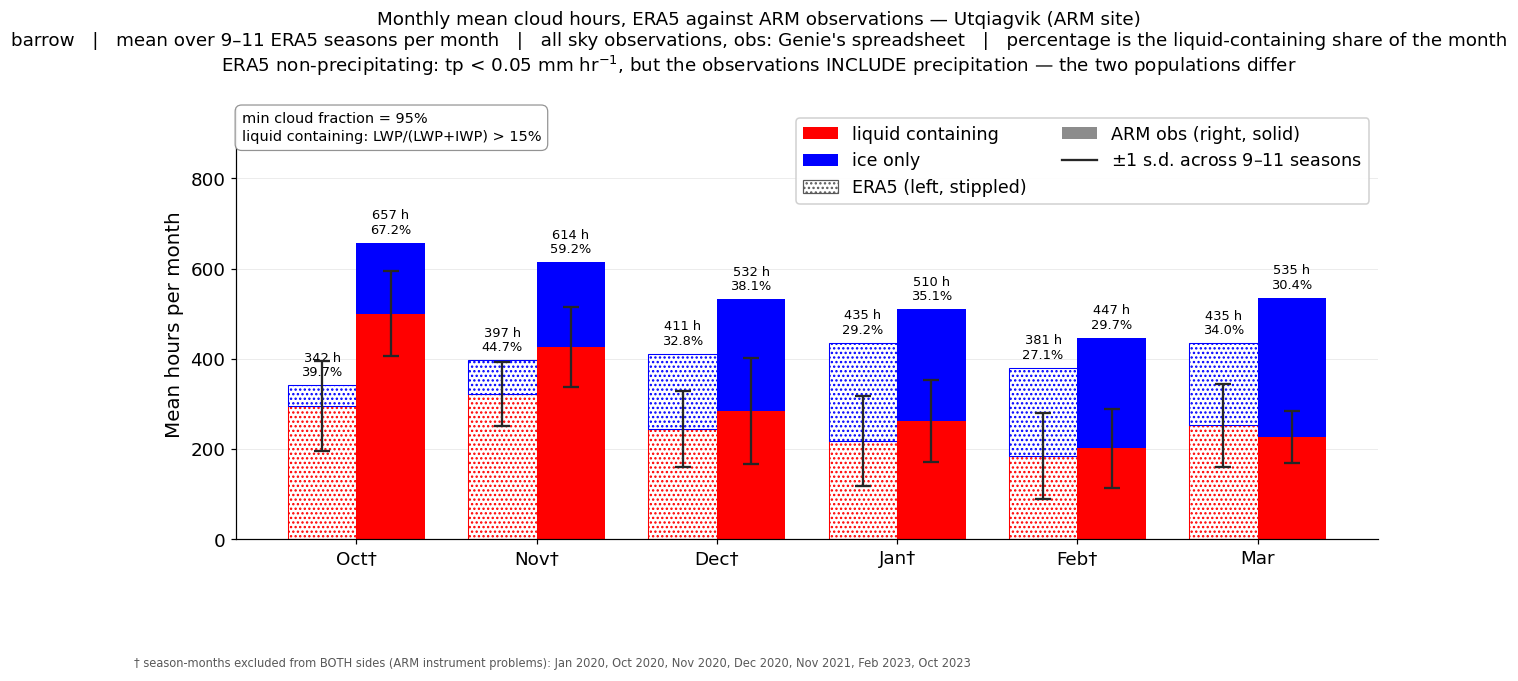

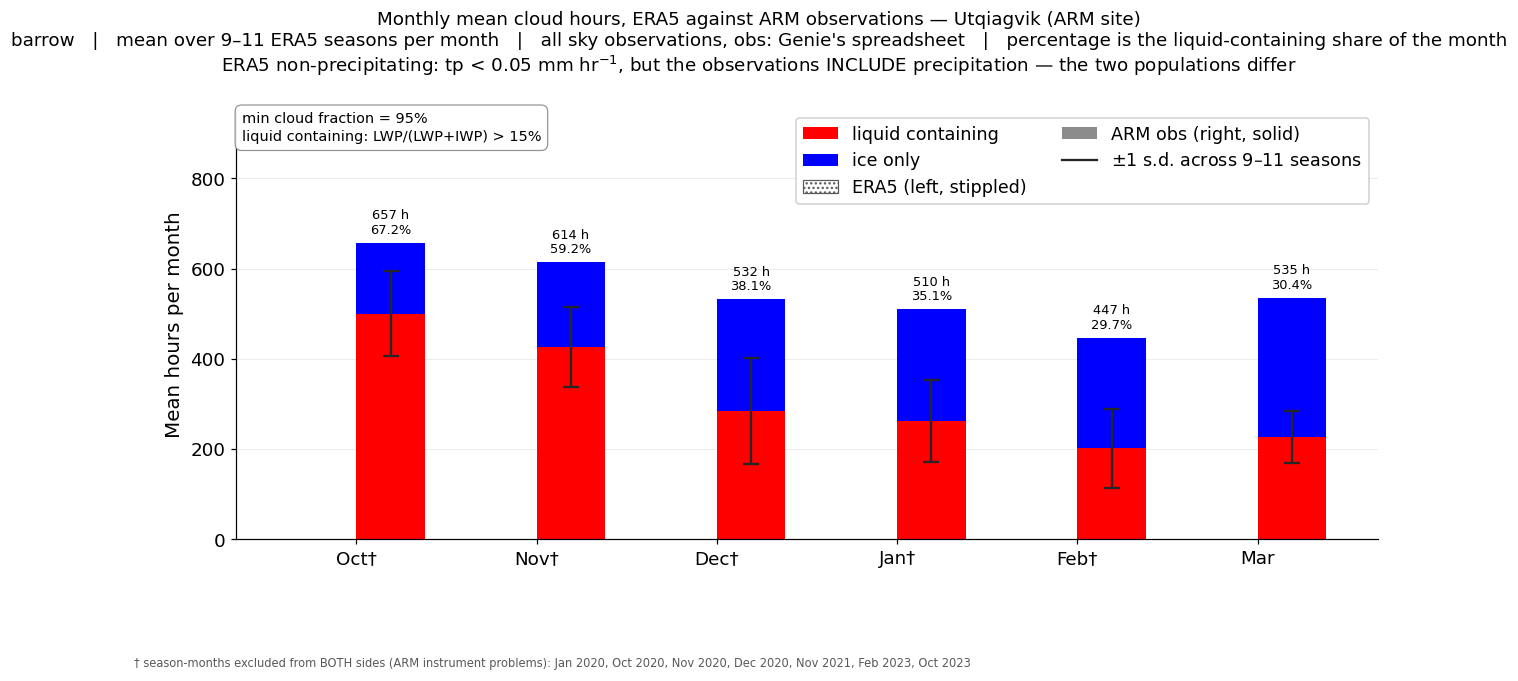

In [22]:
# Precipitation filtered on the ERA5 side only. allow_precip_mismatch=True
# is required: the observations cannot follow the filter, and the figure
# states that on its own title line.
mp_obs, mp_both, mp_full = lwph.fig_monthly_era5_vs_obs_build(
    A_precip, out_dir=SAVE_DIR, allow_precip_mismatch=True)

In [23]:
# Month-by-month residual table, same numbers as the lower panel above.
lwph.table_monthly_era5_vs_obs_pct_diff(A, out_dir=SAVE_DIR, font_size=14);

  -> figures/genie_comparison/barrow_monthly_era5_vs_obs_pct_diff_table_mcf0.95_ifm0.9.png


### The numbers behind it

Per month, both sides and the residual.

In [24]:
import calendar
import numpy as np

obs_m = lwph.load_monthly_observations()
months, liq, ice, month_h = lwph.monthly_phase_binary(A)   # exclusions applied
oi = {m: i for i, m in enumerate(obs_m["months"])}

print(f"excluded season-months: "
      f"{', '.join(f'{calendar.month_abbr[m]} {y}' for y, m in lwph.GENIE_EXCLUDED_MONTHS)}\n")
print(f"{'month':<7}{'n':>3}{'ERA5 liq':>10}{'sd':>7}{'obs liq':>9}{'diff':>8}"
      f"{'%':>8}{'ERA5 ice':>11}{'obs ice':>9}{'diff':>8}{'%':>8}{'of':>7}")
for j, m in enumerate(months):
    if m not in oi:
        continue
    n = int(np.isfinite(liq[:, j]).sum())
    el, ei_ = np.nanmean(liq[:, j]), np.nanmean(ice[:, j])
    sd = np.nanstd(liq[:, j])
    ol, oiq = obs_m["with_liquid"][oi[m]], obs_m["ice_only"][oi[m]]
    print(f"{calendar.month_abbr[m]:<7}{n:>3}{el:>10.0f}{sd:>7.0f}{ol:>9.0f}"
          f"{el-ol:>+8.0f}{100*(el-ol)/ol:>+7.1f}%"
          f"{ei_:>11.0f}{oiq:>9.0f}{ei_-oiq:>+8.0f}{100*(ei_-oiq)/oiq:>+7.1f}%"
          f"{month_h[j]:>7.0f}")

# What the exclusion is worth, month by month.
_, liq0, ice0, _ = lwph.monthly_phase_binary(A, exclude_months=())
print(f"\neffect of the exclusion on the ERA5 monthly means [h]:")
print("  " + "  ".join(
    f"{calendar.month_abbr[m]}{np.nanmean(liq[:, j])-np.nanmean(liq0[:, j]):+.0f}"
    f"/{np.nanmean(ice[:, j])-np.nanmean(ice0[:, j]):+.0f}"
    for j, m in enumerate(months)) + "   (liquid/ice)")

excluded season-months: Jan 2020, Oct 2020, Nov 2020, Dec 2020, Nov 2021, Feb 2023, Oct 2023

month    n  ERA5 liq     sd  obs liq    diff       %   ERA5 ice  obs ice    diff       %     of
Oct      9       404     99      500     -96  -19.2%         68      157     -89  -56.7%    744
Nov      9       420     57      426      -6   -1.4%         98      188     -90  -47.9%    720
Dec     10       276     83      283      -7   -2.5%        195      249     -54  -21.6%    744
Jan     10       262    107      261      +0   +0.1%        230      248     -19   -7.5%    744
Feb     10       226    115      201     +25  +12.4%        224      245     -21   -8.7%    679
Mar     11       294     95      226     +68  +30.0%        189      309    -121  -39.0%    744

effect of the exclusion on the ERA5 monthly means [h]:
  Oct+8/-5  Nov+5/-7  Dec-1/-5  Jan+11/-1  Feb+7/-13  Mar+0/+0   (liquid/ice)


## 7b. Monthly distributions — box and whisker

The bar chart in section 7 shows the **mean** over seasons; this shows the
**distribution** the mean was taken over. It needs every season on both sides,
which only the spreadsheet source provides — the digitised file holds means
alone, and the figure refuses it.

Per month, two boxes: ERA5 on the left in **dotted** lines — the line-art
analogue of the bar chart's stippling — and the observations on the right in
solid lines. Each box is the interquartile range across seasons, the black line
inside it the median (dotted for ERA5, solid for the observations), and the
whiskers reach the minimum and maximum. **No points are drawn as outliers**:
`whis=(0, 100)` puts the whiskers at the full range, so every season is inside
them. The count under each month is the number of seasons behind the box,
which the excluded months make vary from 9 to 11.

The lower panel is the percent difference between the two **medians**,
$100\,(\tilde{x}_{\text{ERA5}} - \tilde{x}_{\text{obs}})/\tilde{x}_{\text{obs}}$.
A median is the right centre for this panel because the bar chart already
reports the mean and a distribution this skewed — see December's whisker
reaching 17 h — pulls the two apart.

Three frames, built as in sections 5 and 7: observations alone, then ERA5
beside them (these two overlay exactly), then the median-difference panel
added. `category` selects `"liquid_containing"` or `"ice_only"`.

  -> figures/genie_comparison/barrow_monthly_box_liquid_containing_era5_vs_obs_mean2014-2024 - build1-obs.png
  -> figures/genie_comparison/barrow_monthly_box_liquid_containing_era5_vs_obs_mean2014-2024 - build2-both.png
  -> figures/genie_comparison/barrow_monthly_box_liquid_containing_era5_vs_obs_mean2014-2024 - build3-full.png


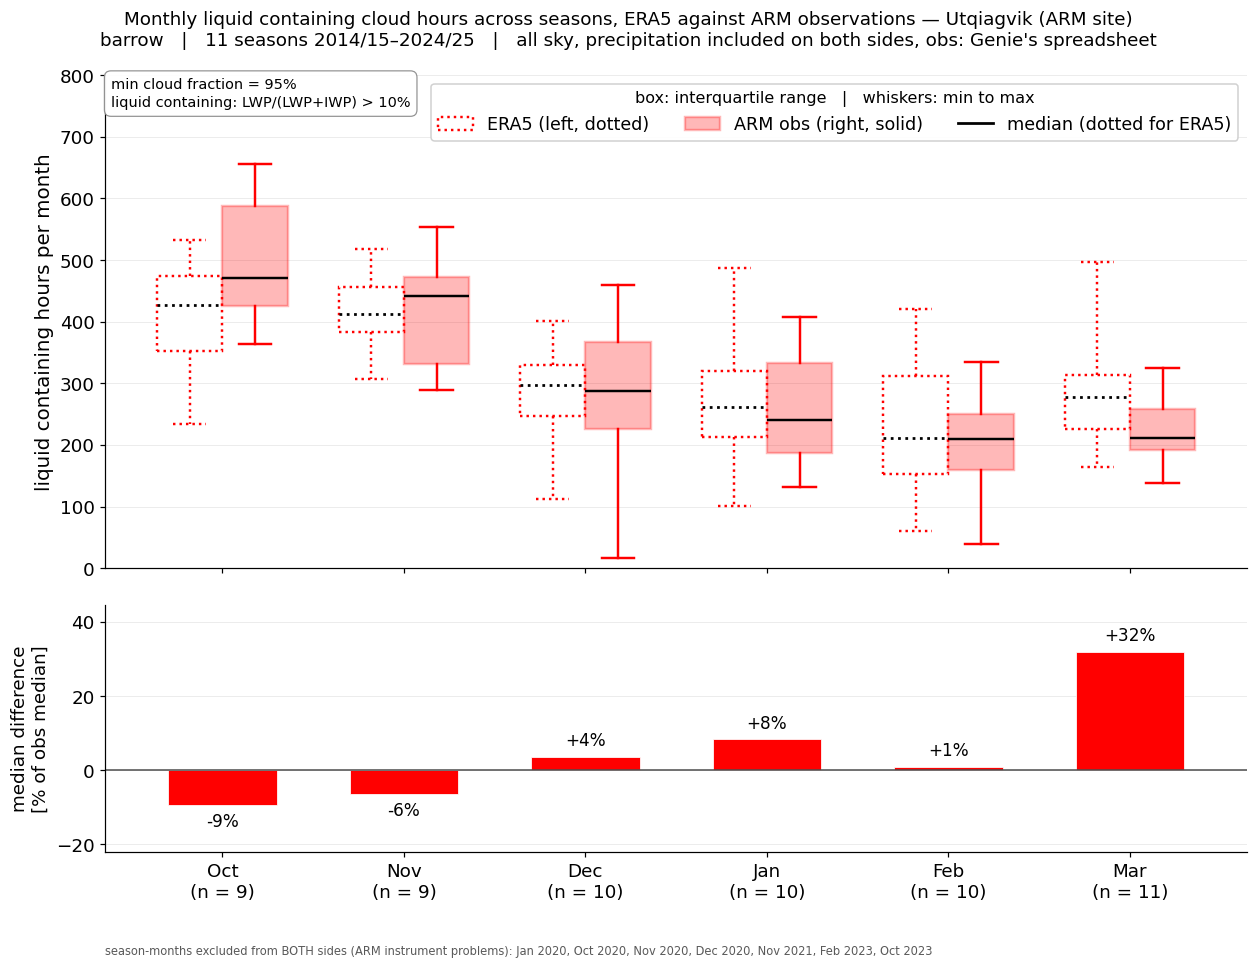

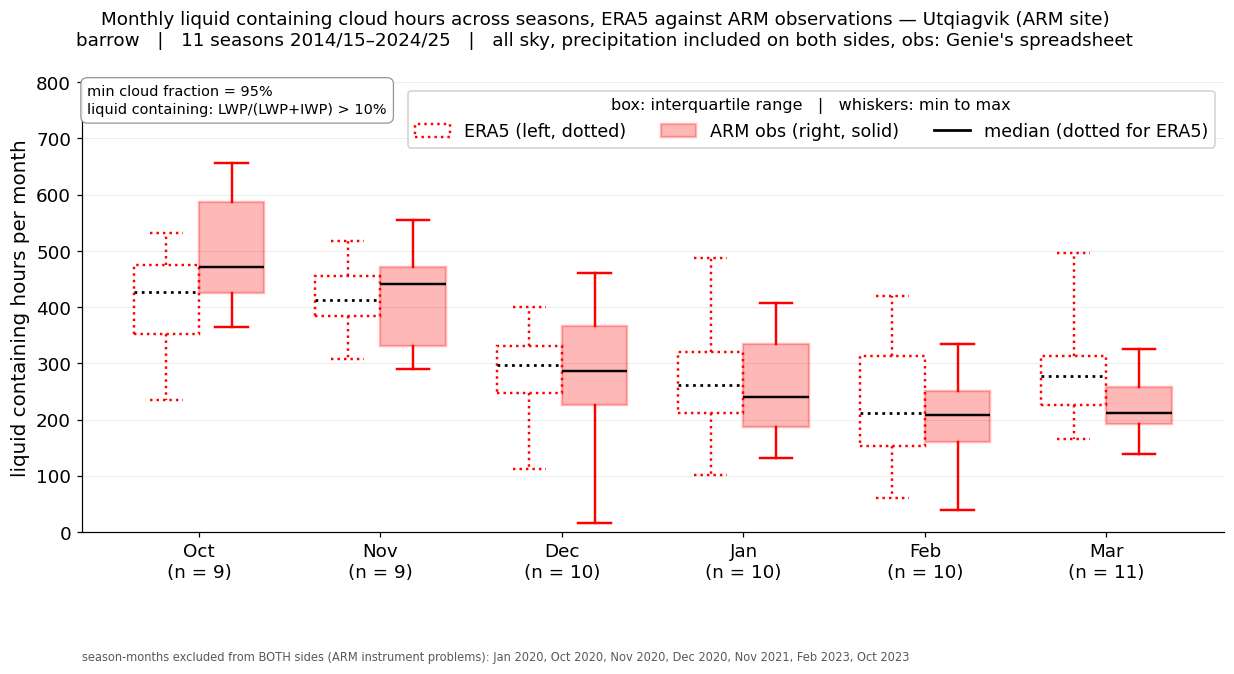

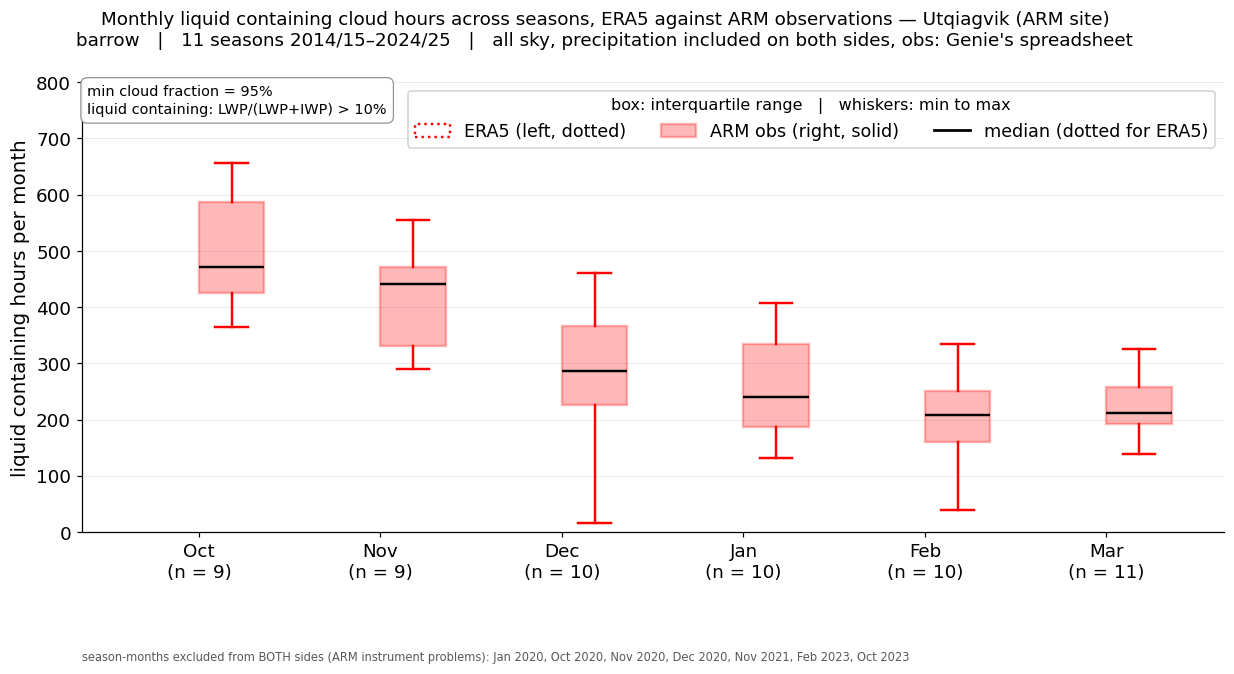

In [25]:
# Liquid containing -- the primary quantity.
b_obs, b_both, b_full = lwph.fig_monthly_box_era5_vs_obs_build(
    A, out_dir=SAVE_DIR, category="liquid_containing")

### Ice only

The same construction for the other category, since ERA5's ice deficit is the
robust finding from section 7 and the distribution shows whether it is a shift
of the whole population or a few seasons.

  -> figures/genie_comparison/barrow_monthly_box_ice_only_era5_vs_obs_mean2014-2024 - build1-obs.png
  -> figures/genie_comparison/barrow_monthly_box_ice_only_era5_vs_obs_mean2014-2024 - build2-both.png
  -> figures/genie_comparison/barrow_monthly_box_ice_only_era5_vs_obs_mean2014-2024 - build3-full.png


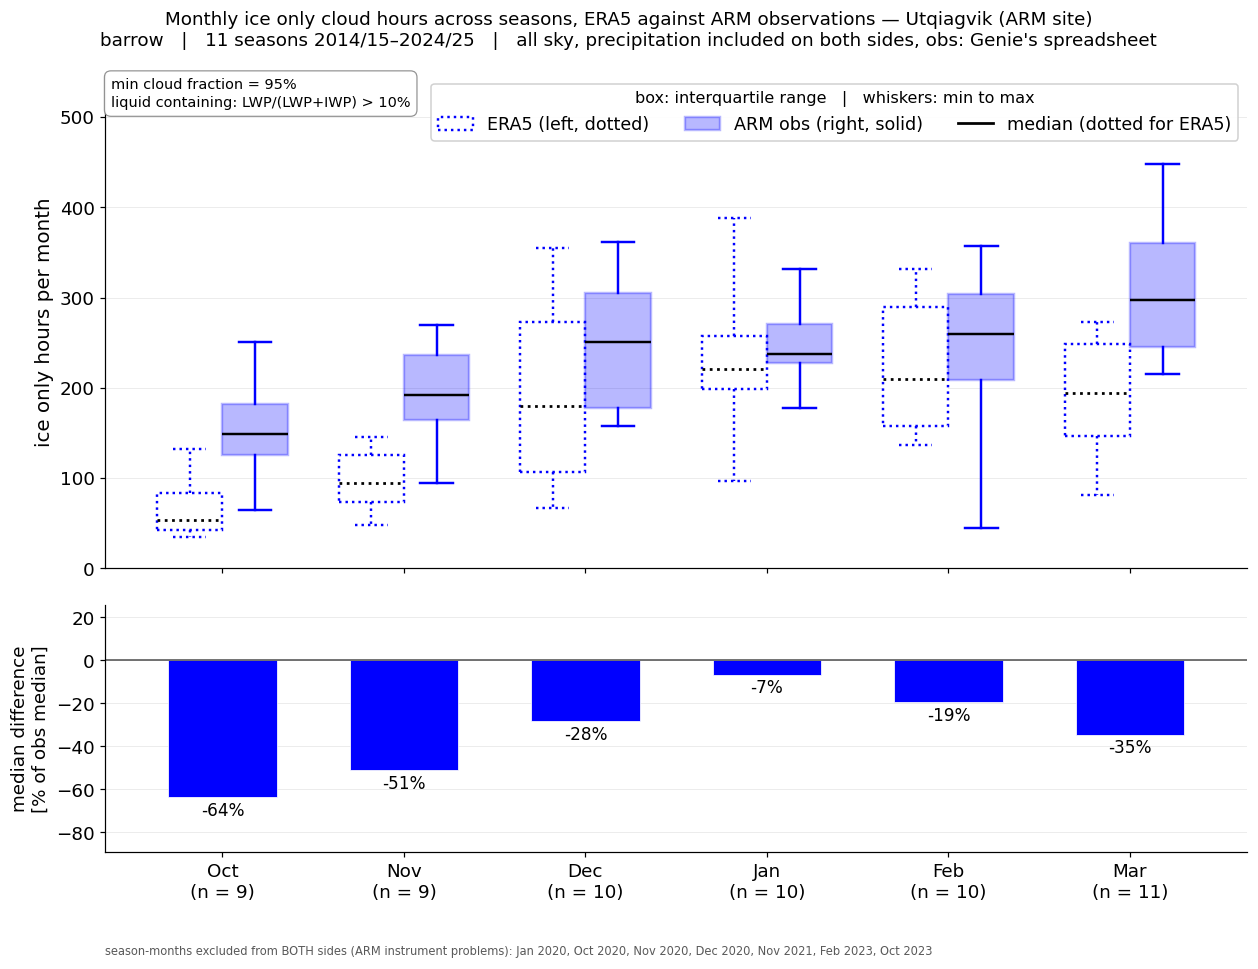

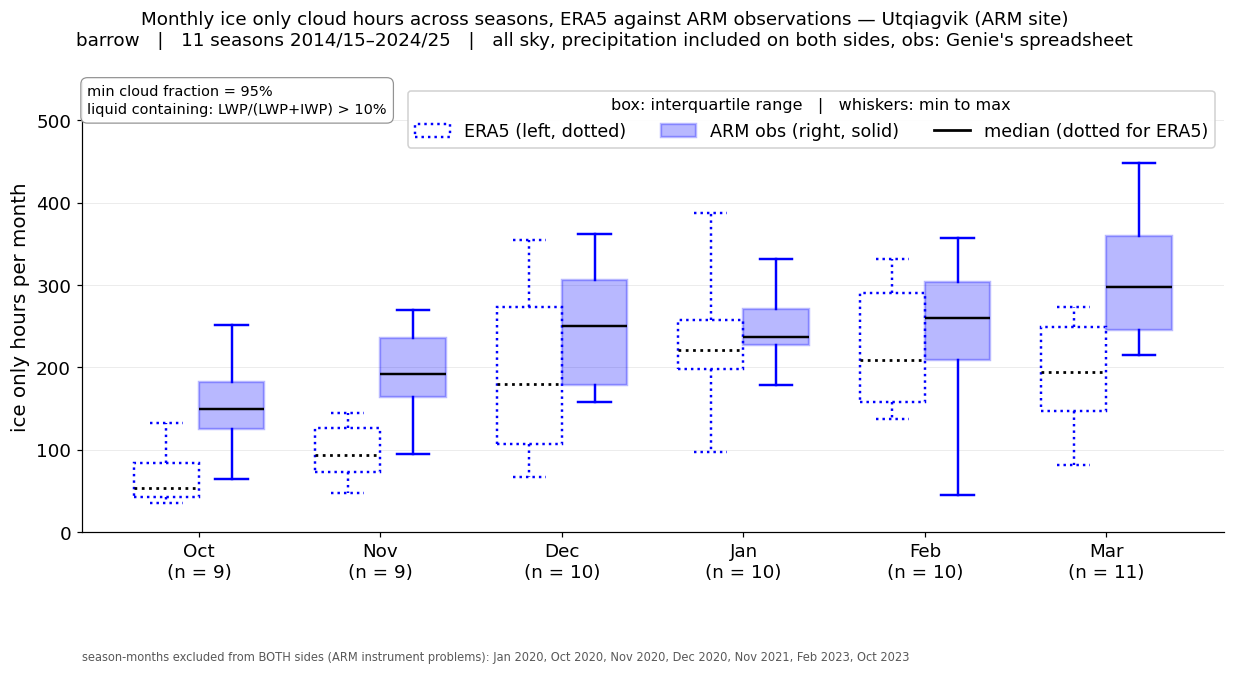

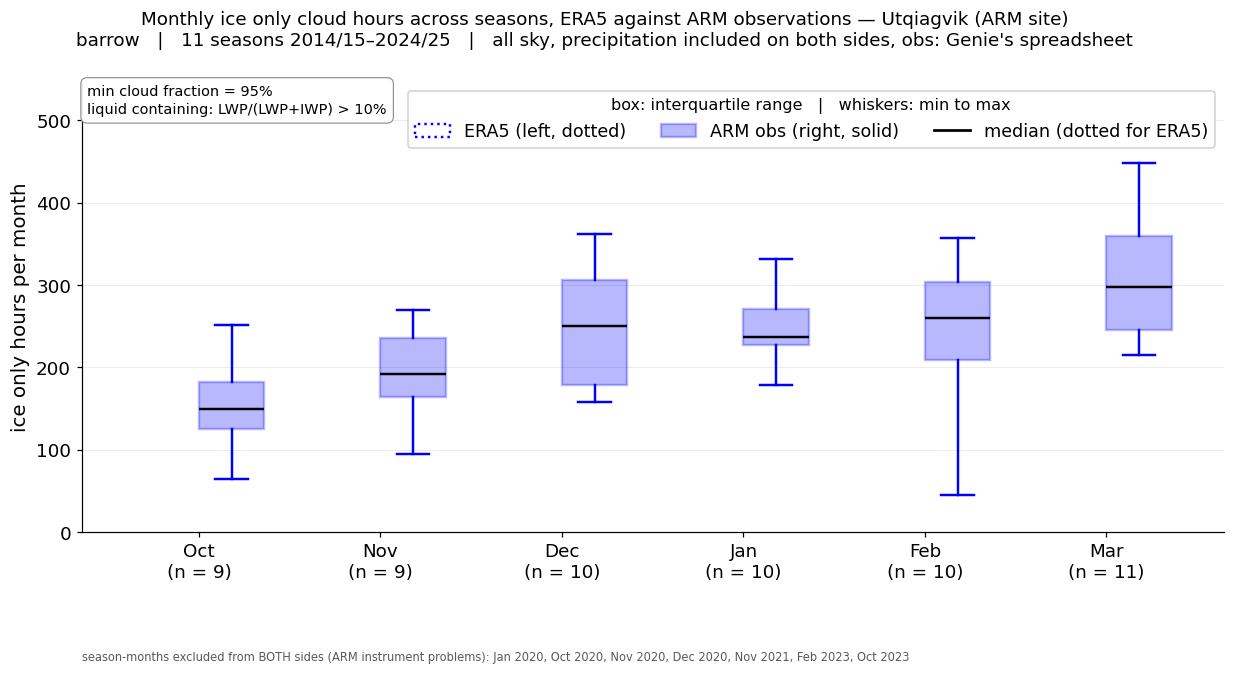

In [26]:
bi_obs, bi_both, bi_full = lwph.fig_monthly_box_era5_vs_obs_build(
    A, out_dir=SAVE_DIR, category="ice_only")

### Liquid water path in liquid-containing cloud — ERA5 only

A different population from the two box plots above. Those summarise **eleven
seasonal values** per month; this one summarises **every liquid-containing
hour** in the month across the kept seasons — a few thousand hourly LWP values
per box. It answers "what LWP does a liquid-containing cloud have in October",
not "how does October's total vary from year to year".

Same conventions: interquartile range, median as a line, whiskers at the
minimum and maximum, nothing drawn as an outlier. Dotted, as ERA5 is throughout
this section, and centred on the month — when Genie's LWP arrives the boxes
move to the left and hers go on the right.

**The log axis is not optional.** With whiskers at the full range, the maximum
is 250–470 g m⁻² from a single thick cloud while the median is 10–76, and a
linear axis would flatten every box to a line. The project's LWP histograms use
a log axis for the same reason.

Built on the per-hour table from `fit_cloud_thresholds.extract_site_series` —
the same table section 8's fit uses, and the liquid-containing test it applies
is the one verified there against the module's own hour counts. The excluded
season-months are dropped to match the other 7b figures.

  -> figures/genie_comparison/barrow_monthly_lwp_box_era5_noprecip_mean2014-2024.png


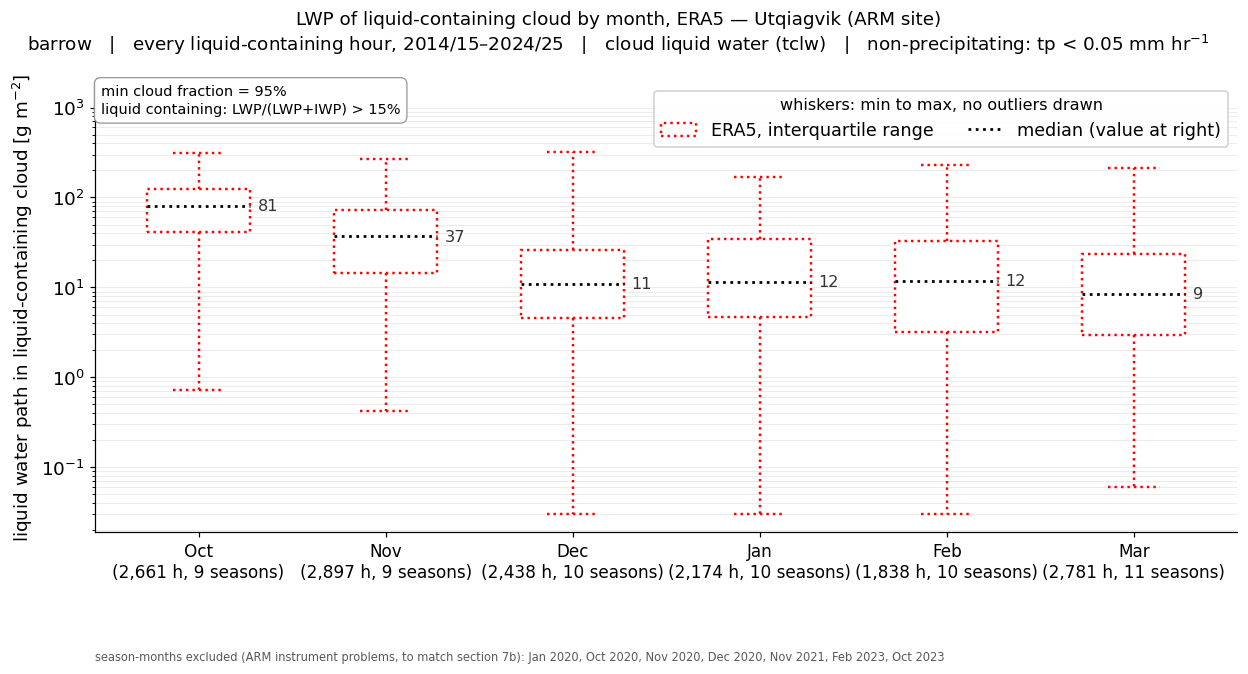

In [27]:
import fit_cloud_thresholds as fit

# One streaming pass per run over the archive for the ARM cell, ~40 s each.
# Section 8 reuses both tables, so they are built once here and passed along.
S_allsky = fit.extract_site_series(A)
S_precip = fit.extract_site_series(A_precip)

# Precipitation filtered, as the section-5 comparison is. --box-y-scale (or
# y_scale=) toggles log/linear; log is the default.
lwph.fig_monthly_lwp_box(A_precip, S=S_precip, out_dir=SAVE_DIR, y_scale="log");

In [28]:
import calendar

months, dist, n_seasons = lwph.monthly_lwp_distributions(A_precip, S_precip)
print(f"{'month':<6}{'hours':>8}{'seasons':>9}{'median':>9}{'q25':>7}{'q75':>7}"
      f"{'min':>8}{'max':>9}   [g m-2]")
for j, m in enumerate(months):
    d = dist[m]
    print(f"{calendar.month_abbr[m]:<6}{d.size:>8,}{n_seasons[j]:>9}"
          f"{np.median(d):>9.1f}{np.percentile(d, 25):>7.1f}"
          f"{np.percentile(d, 75):>7.1f}{d.min():>8.3f}{d.max():>9.1f}")
print("\nThe December-February minimum of 0.031 g m-2 is ERA5's storage quantum "
      "for tclw\n(2^-15 kg m-2): the thinnest liquid-containing scene the "
      "archive can hold.")

month    hours  seasons   median    q25    q75     min      max   [g m-2]
Oct      2,661        9     81.0   41.7  123.2   0.732    313.4
Nov      2,897        9     36.9   14.5   72.4   0.427    269.8
Dec      2,438       10     11.0    4.6   25.8   0.031    321.0
Jan      2,174       10     11.5    4.7   34.1   0.031    170.5
Feb      1,838       10     11.9    3.2   32.8   0.031    227.4
Mar      2,781       11      8.5    2.9   23.7   0.061    213.0

The December-February minimum of 0.031 g m-2 is ERA5's storage quantum for tclw
(2^-15 kg m-2): the thinnest liquid-containing scene the archive can hold.


### Duration of liquid-containing cloud events — ERA5 only

New in kind: not how much liquid cloud, but how long each spell of it lasts.
Stepping through the hourly record at the ARM cell, a **cloud event** is a
maximal run of consecutive hours in which every hour meets the
liquid-containing criterion — the `tcc` gate, the phase boundaries, and the
precipitation filter. Its duration is the number of hours, so 1 h is the
shortest possible event and the hourly step is the resolution. One sample per
event, assigned to the month it **started** in.

Three things the construction has to get right, and how it does:

- **A run cannot cross a gap or a season boundary.** The hour before Oct 1 is in
  a different season, six months away. Runs are broken wherever consecutive
  rows are not exactly one hour apart, which also catches missing files.
- **Runs touching a break are censored** — their true length is unknown and the
  recorded length is a lower bound. They are **included** and counted under
  each month, because dropping them would remove the long clouds
  preferentially. In practice it barely matters: 9 of 2,619 events.
- **The precipitation filter splits runs.** A raining hour inside an otherwise
  continuous cloud breaks it into two events. That is the filter's definition
  doing what it says, not an artefact — but it means the filtered and all-sky
  duration distributions differ in kind, not just in count.

Hours are conserved: the sum of all event durations equals the number of
liquid-containing hours exactly (checked: 16,439 = 16,439). Every hour is in
one event and one only.

Same box conventions: IQR, median line, whiskers at the full range, no
outliers. Log axis by default — a month holds hundreds of one-hour events and a
few multi-day ones.

  -> figures/genie_comparison/barrow_monthly_duration_box_era5_noprecip_mean2014-2024.png


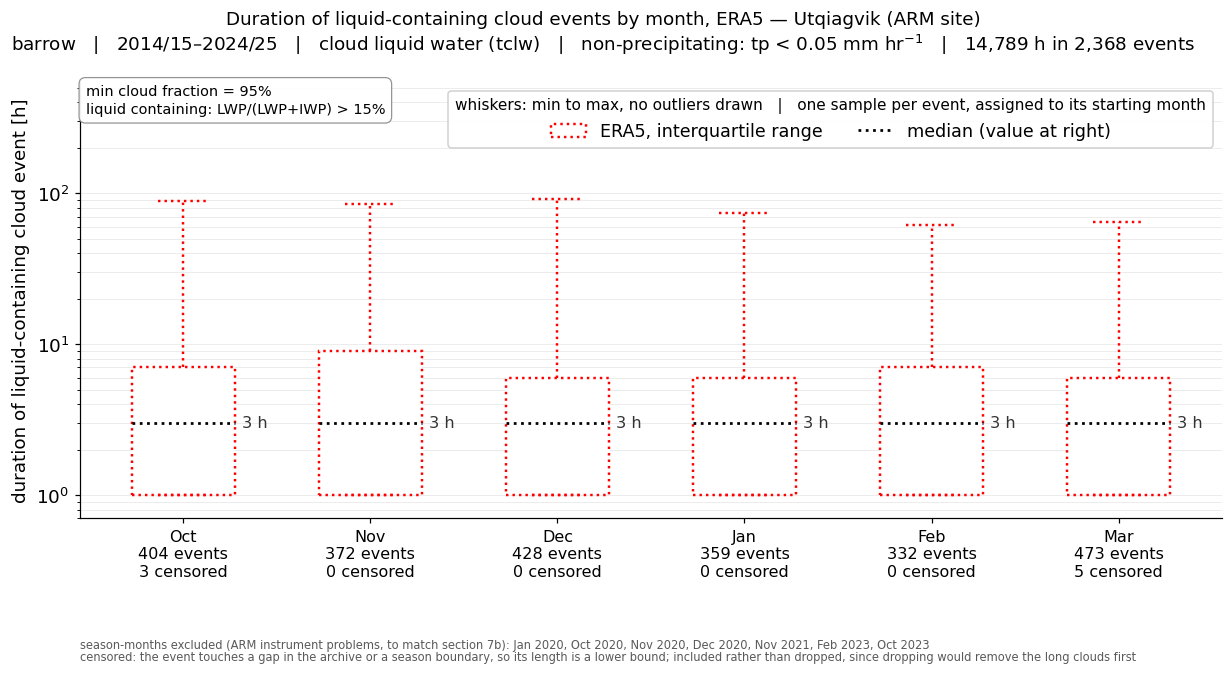

In [29]:
lwph.fig_monthly_duration_box(A_precip, S=S_precip, out_dir=SAVE_DIR);

In [30]:
import calendar

runs = lwph.liquid_cloud_runs(A_precip, S_precip)
L_h = runs["length_h"]
print(f"{'month':<6}{'events':>8}{'censored':>10}{'median':>8}{'q25':>6}{'q75':>6}"
      f"{'max':>6}{'1 h':>8}{'>=6 h':>8}{'>=24 h':>8}   [events: share of month]")
for m in S_precip["months"]:
    d = L_h[runs["month"] == m]
    c = runs["censored"][runs["month"] == m]
    print(f"{calendar.month_abbr[m]:<6}{d.size:>8,}{int(c.sum()):>10}{np.median(d):>8.0f}"
          f"{np.percentile(d, 25):>6.0f}{np.percentile(d, 75):>6.0f}{d.max():>6}"
          f"{100*np.mean(d == 1):>7.1f}%{100*np.mean(d >= 6):>7.1f}%"
          f"{100*np.mean(d >= 24):>7.1f}%")
k = L_h.argmax()
print(f"\nlongest event: {L_h[k]} h = {L_h[k]/24:.1f} days, starting "
      f"{runs['start'][k]}   (censored: {runs['censored'][k]})")
print(f"hours in events {int(L_h.sum()):,}   |   share of hours in events "
      f">= 24 h: {100 * L_h[L_h >= 24].sum() / L_h.sum():.0f}%")

month   events  censored  median   q25   q75   max     1 h   >=6 h  >=24 h   [events: share of month]
Oct        404         3       3     1     7    89   27.7%   34.7%    6.7%
Nov        372         0       3     1     9    85   30.6%   34.7%    7.0%
Dec        428         0       3     1     6    91   27.1%   29.0%    2.1%
Jan        359         0       3     1     6    74   34.5%   28.4%    6.1%
Feb        332         0       3     1     7    62   33.7%   30.1%    3.6%
Mar        473         5       3     1     6    64   32.8%   28.8%    4.0%

longest event: 91 h = 3.8 days, starting 2016-12-16T13   (censored: False)
hours in events 14,789   |   share of hours in events >= 24 h: 30%


## 8. Fitting the two thresholds to the observations

Two knobs decide how many hours ERA5 calls **liquid containing** at the ARM
cell:

| parameter | meaning | range swept |
|---|---|---|
| `min_cloud_fraction` | `tcc ≥ ·` — the overcast gate | 0.90 – 0.99 |
| `ice_fraction_min` | `IWP/(LWP+IWP) ≥ ·` ⇒ ice-only | 0.85 – 0.95 |

A scene is liquid-containing when it is cloudy, holds cloud water above the
minimum paths, and is *not* ice-only — i.e. when its ice share is **below**
`ice_fraction_min`. Note `liquid_fraction_min` is **not** a free parameter: it
moves the liquid-only/mixed boundary, and this merge cannot see it.

Cost is the root-sum-square of the liquid-containing residual, fitted
separately for the three comparisons.

### Why exhaustive grid search, and not an optimiser

Three facts decide this, and they point the same way.

**1. The objective is piecewise constant, so it has no usable gradient.**
Every hour flips category at one discrete threshold. Moving
`min_cloud_fraction` from 0.9500 to 0.9501 changes the answer only if some hour
has `tcc` inside that interval — otherwise the cost is *bit-identical*. The
surface is a staircase: derivative zero almost everywhere, undefined on the
jumps. Gradient descent and L-BFGS have nothing to descend, and a Nelder-Mead
simplex that lands entirely on one tread sees a flat function and collapses.
This rules out the standard optimisers regardless of what an evaluation costs.

**2. Evaluation is essentially free once the archive is read once.** This is
the fact that inverts the usual cost model, and it is the reason not to be
clever. Both parameters are post-hoc scalar tests applied hour by hour, and the
target is **one grid cell** — so a single streaming pass reduces the problem to
a table of ~48,000 rows (season, month, `tcc`, ice share, cloud flag, rain
flag). After that, scoring any pair is two comparisons and a `bincount`: about
a millisecond. A full 91 × 101 grid costs seconds. An optimiser converging in
40 evaluations would save perhaps ten seconds and give up point 3 entirely.

**3. The surface is worth more than the minimum.** Two thresholds that both
remove cloudy hours can trade against each other, and a lone optimum cannot
show that. The full surface separates a sharp, well-identified minimum from a
long diagonal valley in which only *some combination* of the two is
constrained — and it shows whether the minimum sits in the interior or is
pinned to a bound, which is the difference between a fitted value and a bound
the fit wanted to escape.

**Bounding the discretisation error.** Because the cost changes only at values
present in the data, the exact global optimum sits at one of those breakpoints.
A 0.001 grid is finer than either threshold is physically meaningful to, so the
reported optimum is at most one grid step from the exact one — and only inside
a tread where the cost is flat anyway.

### What this is, and is not

**This is calibration, not validation.** Thresholds tuned to reproduce one
observational record cannot then be cited as evidence that ERA5 agrees with it.
The diagnostic use is the honest one: if matching needs a `min_cloud_fraction`
far from 1.0, that says ERA5 needs partly-cloudy scenes counted as overcast to
match a point instrument — a statement about **sampling**, not a tuning knob.

The cost uses the liquid-containing residual alone, as asked, so ice-only is
free to get worse. `report_optimum` prints the ice residual at each optimum as
a check: a fit that repairs liquid while breaking ice has relabelled hours, not
found them.

### Excluded data

Seasons **2016/17, 2019/20, 2020/21 and 2021/22** are dropped from the two
seasonal fits (`fit.EXCLUDED_FIT_SEASONS`). Genie's record is substantially
incomplete in these, and the seasonal file reports the shortfall as raw missing
hours rather than scaling what remains up to a full season — while ERA5 has no
gaps and *is* scaled up. Fitting to them would tune the thresholds to
instrument downtime. The monthly fit uses `GENIE_EXCLUDED_MONTHS` as before.

### 8.1 One pass over the archive

Everything that does not depend on the two free parameters is computed here,
once. The verification is not optional: the fit reimplements the module's
normalisation on a reduced table, so it is only trustworthy if it reproduces
`season_phase_binary` and `monthly_phase_binary` at the run's own thresholds.
`fit.verify` raises if it does not.

In [31]:
import numpy as np

import fit_cloud_thresholds as fit

# S_allsky and S_precip were extracted in section 7b and are reused here.

print(f"{S_allsky['si'].size:,} hours at ({S_allsky['site_lat']:.3f} N, "
      f"{S_allsky['site_lon']:.3f} E)   |   {S_allsky['n_season']} seasons "
      f"x {S_allsky['n_month']} months")
print(f"seasons dropped from the seasonal fits: "
      f"{', '.join(f'{y}/{(y+1)%100:02d}' for y in fit.EXCLUDED_FIT_SEASONS)}")
print(f"precip threshold on the filtered run: "
      f"{S_precip['precip_rate_max']:g} mm/hr\n")

print("verify, all sky:")
fit.verify(S_allsky, A)
print("verify, precipitation filtered:")
fit.verify(S_precip, A_precip)

48,120 hours at (71.250 N, -156.500 E)   |   11 seasons x 6 months
seasons dropped from the seasonal fits: 2016/17, 2019/20, 2020/21, 2021/22
precip threshold on the filtered run: 0.05 mm/hr

verify, all sky:
  seasonal   max |fit - module| =    0.0000 h (OK)
  monthly    max |fit - module| =    0.0000 h (OK)
verify, precipitation filtered:
  seasonal   max |fit - module| =    0.0000 h (OK)


np.True_

### 8.2 The sweep

91 × 101 = 9,191 threshold pairs per target, evaluated exhaustively. Each
target reports its optimum, how many grid cells tie it exactly (a flat tread
means the two thresholds are not separately identified there), whether the
minimum is pinned to a bound, the improvement over the current setting, and —
for the seasonal targets — what happened to ice-only, which is *not* in the
cost.

In [32]:
import time

obs   = lwph.load_observations()
obs_m = lwph.load_monthly_observations()

SERIES   = {"season_noprecip": S_precip, "season_allsky": S_allsky,
            "monthly_allsky": S_allsky}
ANALYSIS = {"season_noprecip": A_precip, "season_allsky": A,
            "monthly_allsky": A}

surfaces, results = {}, {}
for target in fit.TARGETS:
    t0 = time.time()
    tcc_v, ifm_v, cost = fit.cost_surface(SERIES[target.key], target, obs, obs_m)
    surfaces[target.key] = (tcc_v, ifm_v, cost)
    results[target.key] = fit.report_optimum(
        SERIES[target.key], target, obs, obs_m, tcc_v, ifm_v, cost,
        A=ANALYSIS[target.key])
    lo, hi = float(np.nanmin(cost)), float(np.nanmax(cost))
    print(f"  {tcc_v.size} x {ifm_v.size} = {tcc_v.size * ifm_v.size:,} "
          f"evaluations in {time.time() - t0:.1f} s   |   cost spans "
          f"{lo:,.0f}-{hi:,.0f} h   |   {100 * np.mean(cost <= 1.1 * lo):.1f}% "
          f"of the grid is within 10% of the minimum")


Seasonal, precipitation filtered (section 5)
  fitted   min_cloud_fraction = 0.910   ice_fraction_min = 0.854
  RSS      775.0 h   over 7 seasons   (RMS 292.9 h)
  baseline RSS at (0.950, 0.850) = 926.9 h   -> improvement 16.4%
  ice-only RSS at this optimum = 471.0 h   (was 448.6 h at the baseline)   [not minimised]
  91 x 101 = 9,191 evaluations in 1.0 s   |   cost spans 775-1,697 h   |   42.6% of the grid is within 10% of the minimum

Seasonal, all sky (section 6)
  fitted   min_cloud_fraction = 0.910   ice_fraction_min = 0.874
  RSS      699.6 h   over 7 seasons   (RMS 264.4 h)
  baseline RSS at (0.950, 0.900) = 790.7 h   -> improvement 11.5%
  ice-only RSS at this optimum = 452.4 h   (was 663.1 h at the baseline)   [not minimised]
  91 x 101 = 9,191 evaluations in 1.1 s   |   cost spans 700-1,929 h   |   38.0% of the grid is within 10% of the minimum

Monthly means, all sky (section 7)
  fitted   min_cloud_fraction = 0.909   ice_fraction_min = 0.850
  RSS      100.0 h   over 6 mo

### 8.3 The cost surfaces

Each panel is one target. The star is that target's optimum, the open circle
the current setting. Read the **shape** as much as the star: closed contours
around the star mean the pair is identified; a trough running diagonally means
the two thresholds trade against each other and only their combination is
constrained by these data.

  -> figures/genie_comparison/threshold_fit_cost_surfaces.png

target                                tcc  ice frac     RSS h    RMS h    n
Seasonal, precipitation filtered (section 5)  0.910     0.854       775      293    7
Seasonal, all sky (section 6)       0.910     0.874       700      264    7
Monthly means, all sky (section 7)  0.909     0.850       100       41    6

Seasonal, precipitation filtered (section 5)
        2014     2015     2017     2018     2022     2023     2024
       1,922    2,594    1,755    1,529    1,371    1,471    1,909   ERA5
       1,619    2,163    1,724    1,585    1,846    1,768    1,981   obs
        +303     +431      +32      -56     -475     -297      -72   residual

Seasonal, all sky (section 6)
        2014     2015     2017     2018     2022     2023     2024
       2,273    2,784    2,146    1,847    1,749    1,829    2,280   ERA5
       2,009    2,405    2,130    1,811    2,181    2,109    2,378   obs
        +264     +379      +16      +36 

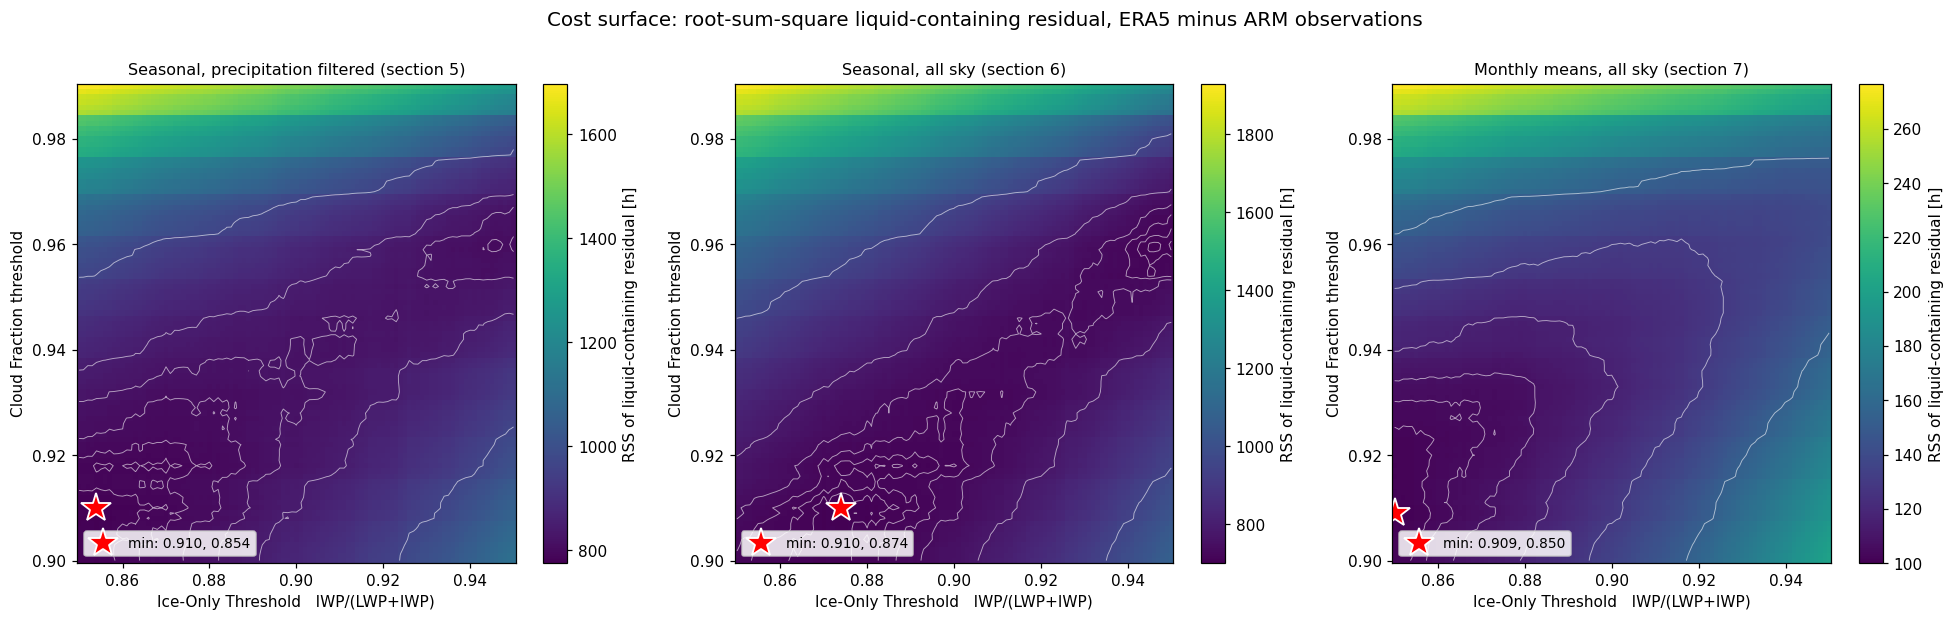

In [33]:
fit.fig_cost_surfaces(S_allsky, results, surfaces, A=A, out_dir=SAVE_DIR)

print(f"\n{'target':<34}{'tcc':>7}{'ice frac':>10}{'RSS h':>10}"
      f"{'RMS h':>9}{'n':>5}")
for target in fit.TARGETS:
    r = results[target.key]
    print(f"{target.label:<34}{r['tcc']:>7.3f}{r['ice_frac']:>10.3f}"
          f"{r['rss']:>10,.0f}{r['rss'] / np.sqrt(len(r['x'])):>9,.0f}"
          f"{len(r['x']):>5}")

# Residuals at each optimum, term by term.
for target in fit.TARGETS:
    r = results[target.key]
    print(f"\n{target.label}")
    print("   " + "".join(f"{str(v):>9}" for v in r["x"]))
    print("   " + "".join(f"{v:>9,.0f}" for v in r["era5"]) + "   ERA5")
    print("   " + "".join(f"{v:>9,.0f}" for v in r["obs"]) + "   obs")
    print("   " + "".join(f"{v:>+9,.0f}" for v in (r["era5"] - r["obs"]))
          + "   residual")

## Reading the comparison

Two questions worth separating when the numbers disagree:

1. **Does ERA5 see cloud as often?** Compare the cloudy totals — ERA5's
   overcast hours against her red + pink + blue + light blue.
2. **Given cloud, does ERA5 get the phase split right?** Compare the liquid
   share, which is insensitive to (1) and is the more physically interesting
   question.

They can fail independently: ERA5 could be too cloudy with the right phase mix,
or correctly cloudy with too little liquid. The `liq share` column above is
built for the second question.

If you want to test sensitivity, `min_lwp` / `min_iwp` and `min_cloud_fraction`
are the levers — each needs a fresh `prepare()`. `liquid_fraction_min` and
`ice_fraction_min` change where the liquid/mixed/ice boundaries fall but not the
liquid-containing vs ice-only split, since that merge is insensitive to the
liquid–mixed boundary.